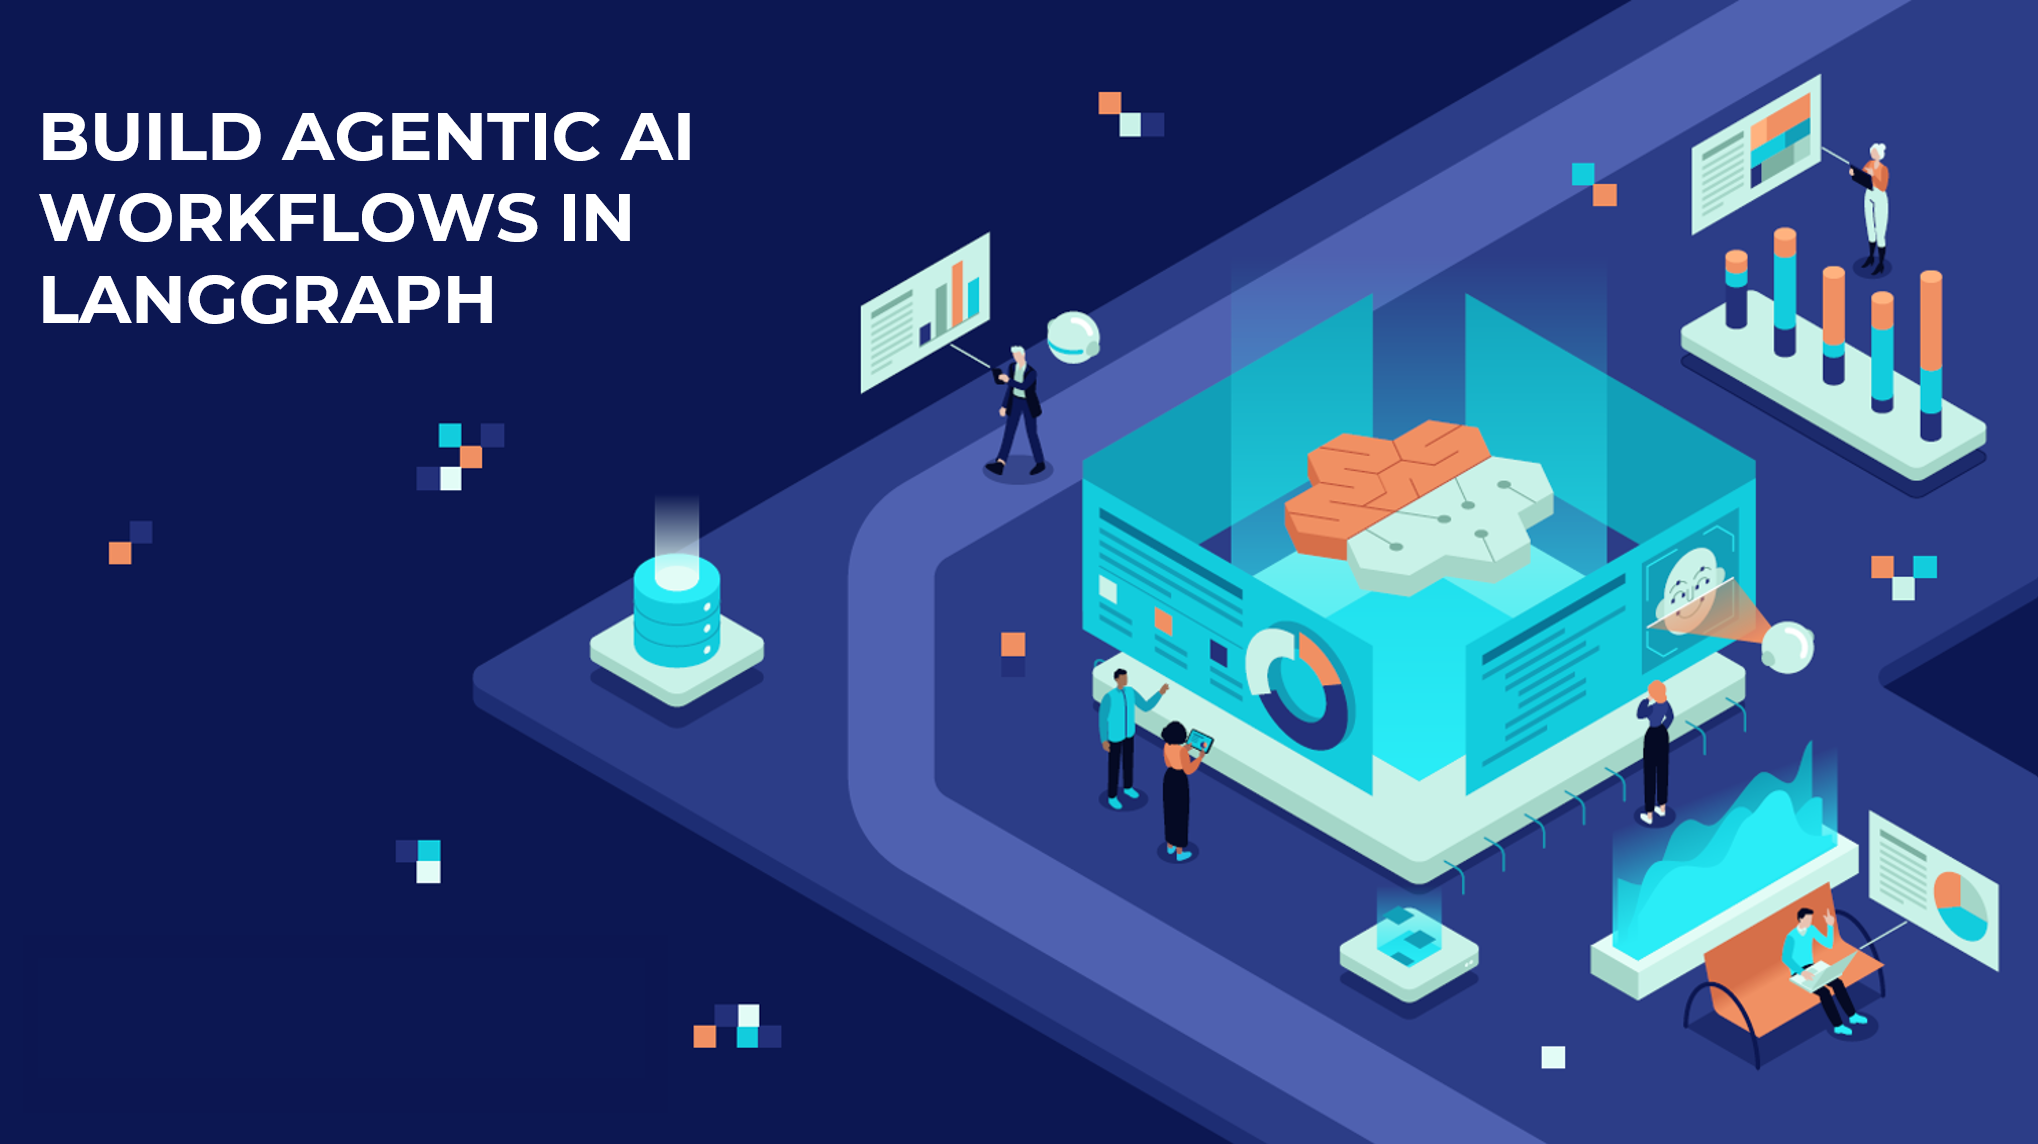

# TASK 1: PROJECT OVERVIEW: THE AI TRAVEL AGENT

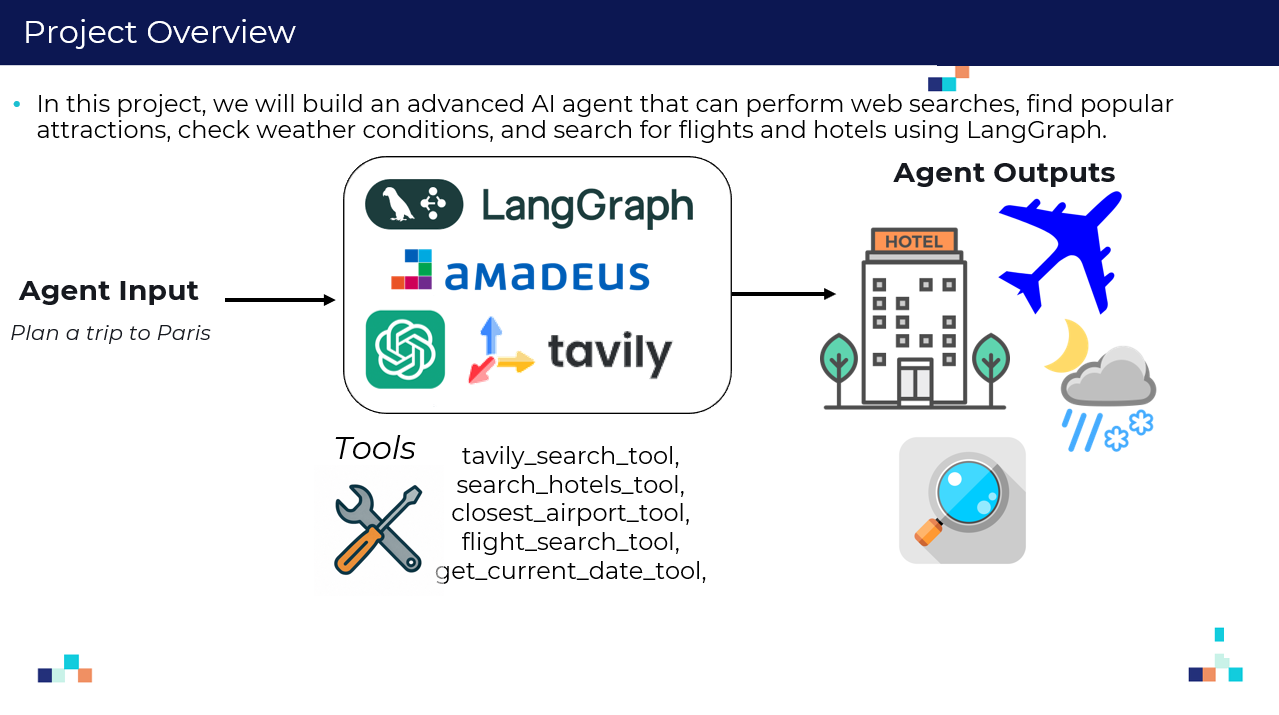

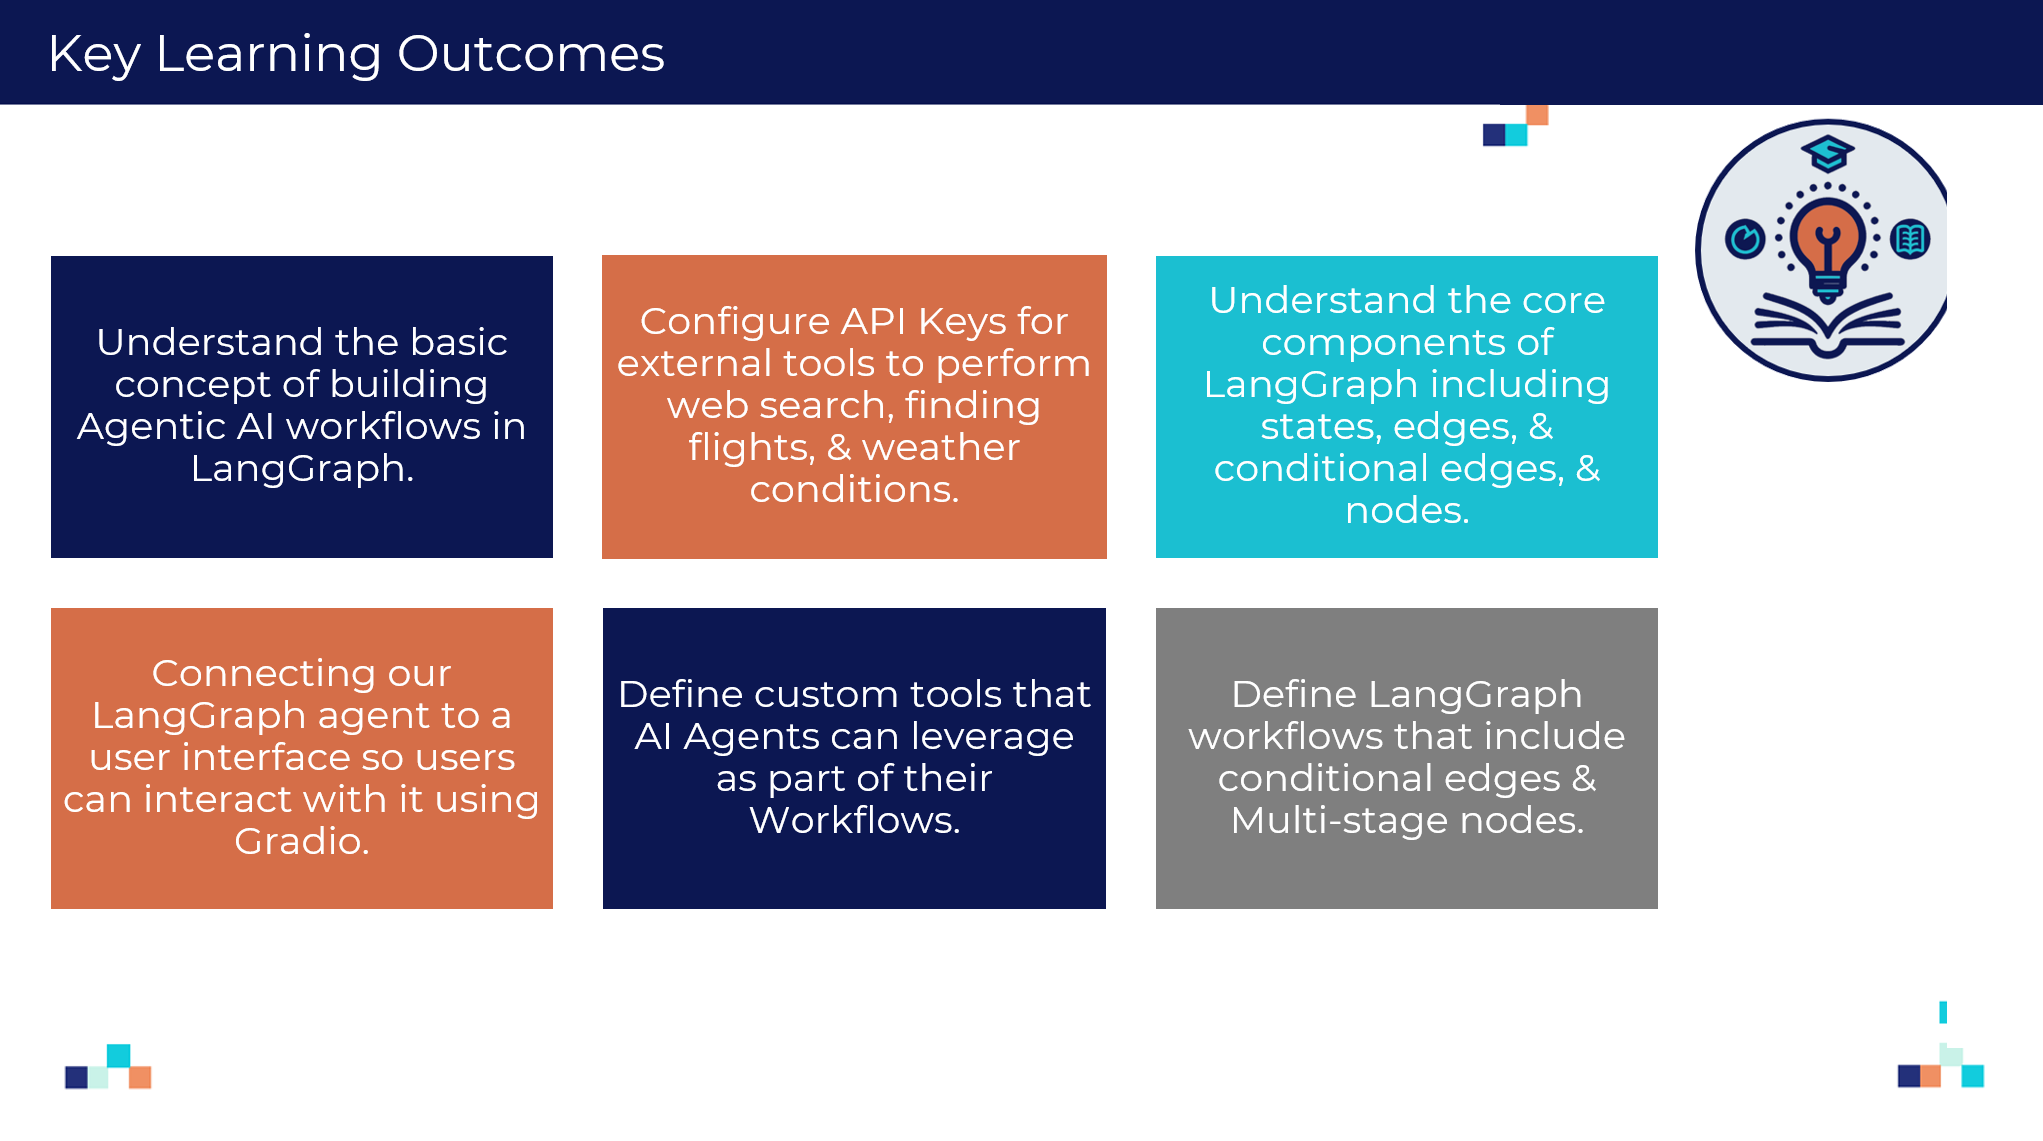

# TASK 2: UNDERSTAND LANGGRAPH & ITS KEY COMPONENTS & FEATURES 

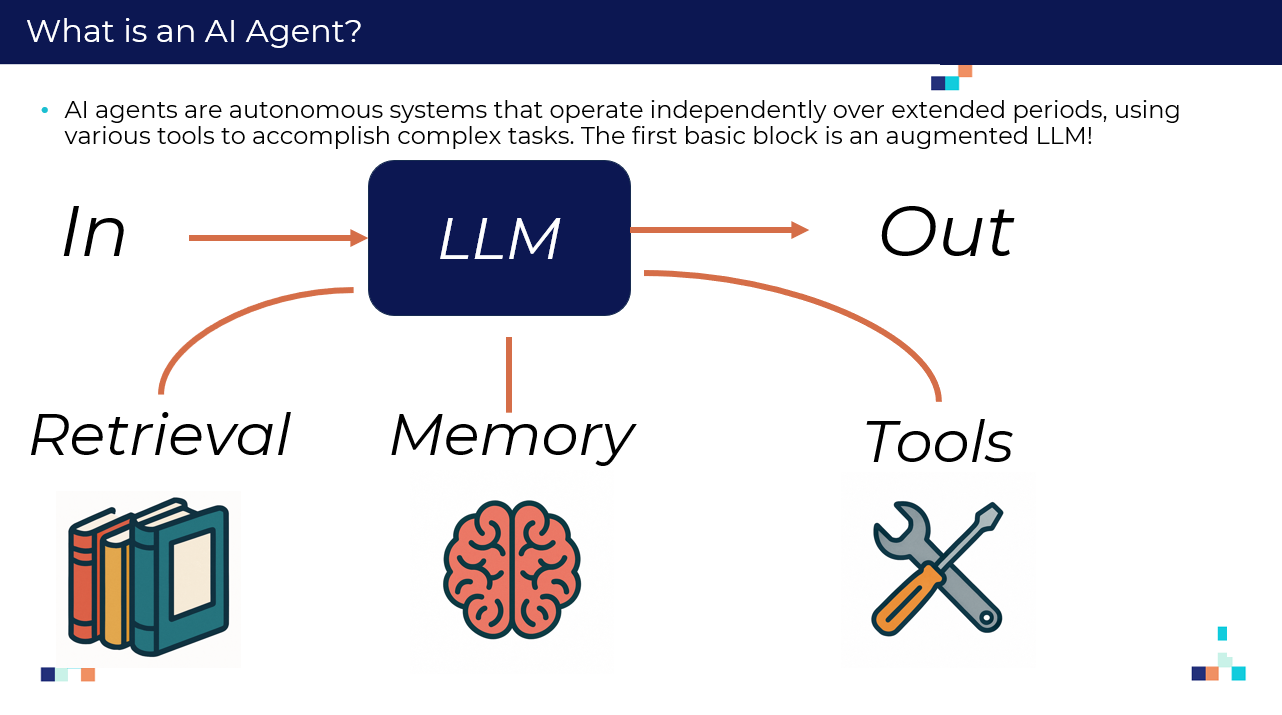

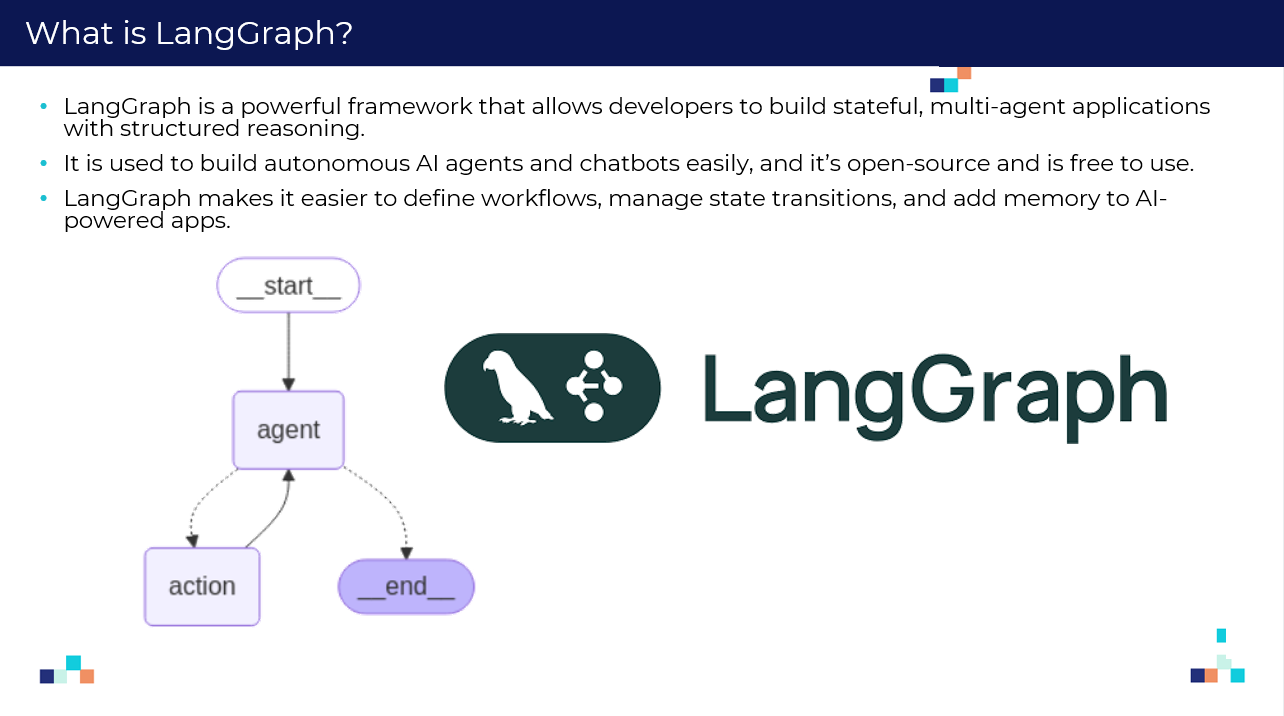

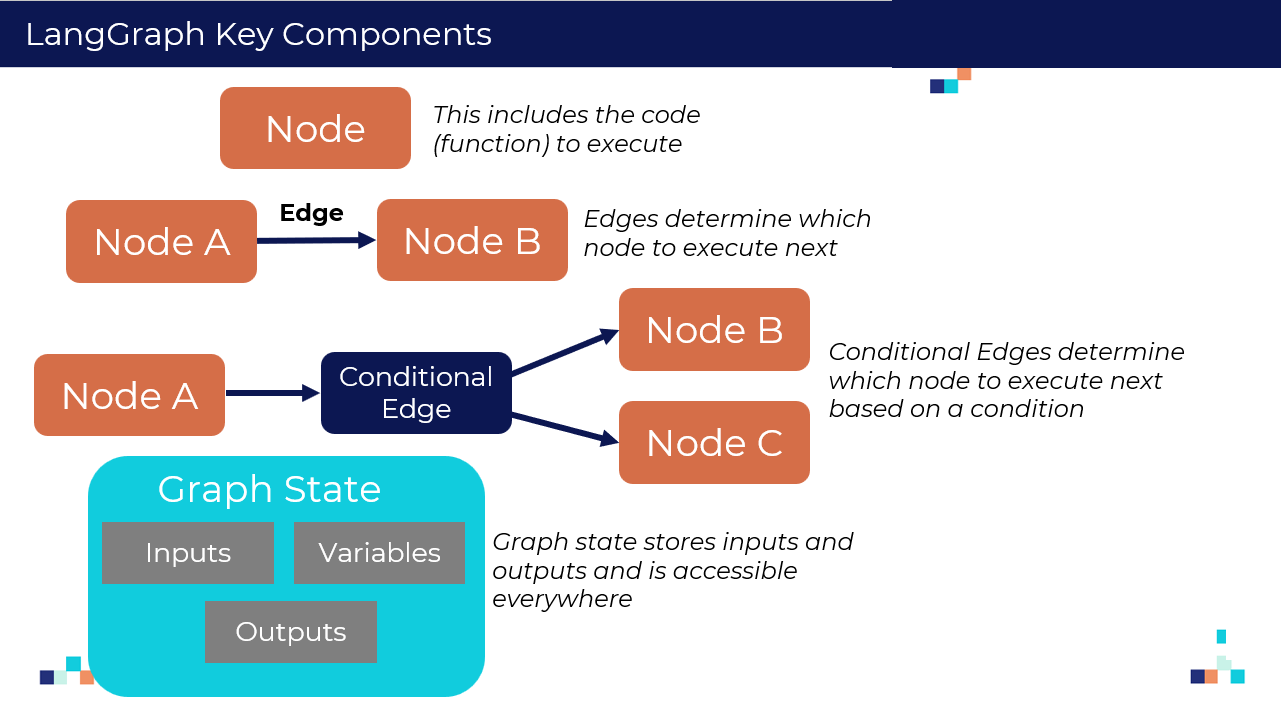

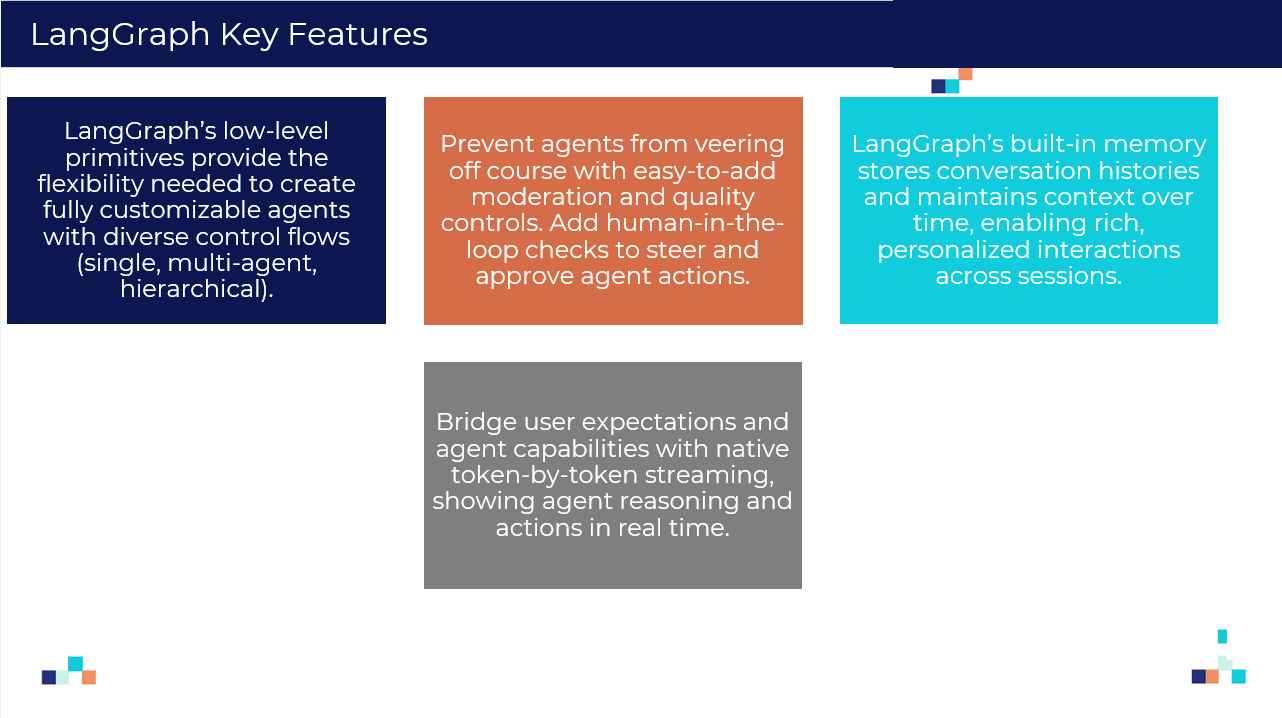

# TASK 3: BUILD OUR FIRST AGENTIC WORKFLOW IN LANGGRAPH (SUMMARIZATION AGENT) WITH NO TOOLS

LangGraph is a powerful library built on top of LangChain that focuses on creating stateful, multi-agent workflows using a graph structure. Let's start with the fundamental structure of LangGraph. We'll build a simple agent that just calls the LLM without any external tools. This helps understand the core concepts: State, Nodes, and Edges.

Key Components of LangGraph

- **StateGraph:** The core object for building workflows
- **Nodes:** Functions or agents that perform specific tasks
- **Edges:** Connections between nodes that control flow
- **State:** Information that persists across nodes
- **Conditional Routing:** Logic for determining which path to follow

In [ ]:
# Install necessary libraries
# We need langchain, langgraph, OpenAI integration, Tavily, Duffel REST calls, and Gradio
# %pip installs into the SAME Python running this kernel (unlike "! pip").
%pip install -q --upgrade langchain langgraph langchain_openai tavily-python python-dotenv gradio langchain_community graphviz requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# Import necessary libraries
import os
import uuid
import getpass
from typing import TypedDict, Annotated, Sequence, List, Tuple, Optional, Any, Union, Literal,  Tuple
import operator
from datetime import date
from IPython.display import display, Markdown, Image
from graphviz import Source
import uuid  # Added for Gradio state

# Langchain specific imports
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage, ToolMessage, HumanMessage, AIMessage, SystemMessage
from langchain.tools import tool
from pydantic import BaseModel  # For tool args schema if needed explicitly

# LangGraph imports (Updated based on recent versions)
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode  # Preferred way to handle tool execution

# Gradio
import gradio as gr

# Load environment variables
from dotenv import load_dotenv
load_dotenv(override=True)

# Set environment variables (especially useful for LangChain integrations)
openai_api_key = os.environ["OPENAI_API_KEY"]

print("API Keys loaded (partially hidden for security):")
print(f"OpenAI Key starts with: {openai_api_key[:5]}...")


API Keys loaded (partially hidden for security):
OpenAI Key starts with: sk-pr...


In [4]:
# Helper function to display markdown nicely
def print_markdown(text):
    """Displays text as Markdown in Jupyter."""
    display(Markdown(text))

In [5]:
# Let's define a simple workflow that includes a summarization function
# Let's define a state that includes two information: the original text and its summary
# State is how information persists and flows between nodes
# The state is like a container that stores and passes data between different parts of our workflow
# Each node receives and returns a state object, and the State can include messages, variables, memory, etc.

class AgentState(TypedDict):
    input_text: str
    summary: str

In [6]:
# Let's define the key node, which represents the functions that perform specific tasks in your graph
# They receive the current state and return a modified state
# Note that a node can be simple functions, LLM calls, or complex agents

def summarize_step(state: AgentState) -> AgentState:
    """Create a concise summary of the input text."""
    
    # Initialize the OpenAI model and define the prompt
    llm = ChatOpenAI(model = "gpt-3.5-turbo")
    prompt = f"Please summarize the following text in one sentence that captures the main points: {state['input_text']}"
    
    # Get the summary directly from the model
    result = llm.invoke([prompt])
    
    # Update the state with our summary
    return {
        "input_text": state["input_text"],  # Keep the original text
        "summary": result.content  # Add the summary
    }

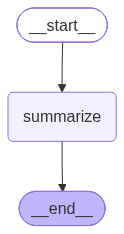

In [7]:
# Let's define our StateGraph, which is the fundamental building block of LangGraph
# It manages the flow of information between different components
# It maintains state throughout the execution of your workflow

# Let's define a stategraph with the "AgentState" we defined earlier
workflow = StateGraph(AgentState)

# Let's add a node, which is the summarize function we defined before
workflow.add_node("summarize", summarize_step)

# Let's define Edges, which define how data flows between nodes
workflow.add_edge("summarize", END) 
workflow.set_entry_point("summarize")
workflow.compile()

In [8]:
# Now we are ready to compile and execute the graph 
# After defining your graph, you need to compile it to create an executable workflow
# Invoke it with an initial state to run the entire process

# Example text to summarize
sample_text = """
    Electric cars work by using electricity stored in a battery pack to power an electric motor, which drives the wheels. 
    Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVS) use electric motors that are more efficient and produce zero emissions during operation. 
    When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car. 
    The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. 
    Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
    """
    
# Let's compile the graph
graph = workflow.compile() 

# Set up the initial state with the input text
initial_state = {
        "input_text": sample_text,
        "summary": ""}
    
# Run the graph
result = graph.invoke(initial_state)
    
# Get the summary from the result
summary = result["summary"]
    
# Print the result
print(summary)

Electric cars use electricity stored in a battery pack to power an electric motor, which drives the wheels more efficiently and with zero emissions, recharging the battery through an external power source and sometimes using regenerative braking to improve efficiency.


**PRACTICE OPPORTUNITY:**
- **Change the input message to summarize a different text:**
"The internet is a global network that connects millions of computers and devices, allowing people to share information, communicate, and access services from anywhere in the world. It works by transmitting data through a complex system of servers, cables, and wireless signals. The internet has transformed how we live, work, and learn—making it easy to search for knowledge, shop online, stream videos, use social media, and stay in touch with others. It continues to evolve, shaping nearly every aspect of modern life."

- **Rerun the workflow and assess the output**

In [9]:
sample_text = """The internet is a global network that connects millions of computers and devices, allowing people to share information, communicate, and access services from anywhere in the world. 
It works by transmitting data through a complex system of servers, cables, and wireless signals. 
The internet has transformed how we live, work, and learn—making it easy to search for knowledge, shop online, 
stream videos, use social media, and stay in touch with others. It continues to evolve, shaping nearly every aspect of modern life."""

# Let's compile the graph
graph = workflow.compile() 

# Set up the initial state with the input text
initial_state = {
        "input_text": sample_text,
        "summary": ""}
    
# Run the graph
result = graph.invoke(initial_state)
    
# Get the summary from the result
summary = result["summary"]
    
# Print the result
print(summary)


The internet is a global network that enables people to share information, communicate, access services, and has transformed how we live, work, and learn, shaping nearly every aspect of modern life.


# TASK 4: BUILD AN AGENTIC WORKFLOW IN LANGGRAPH (SUMMARIZATION + TRANSLATION AGENT) WITH NO TOOLS

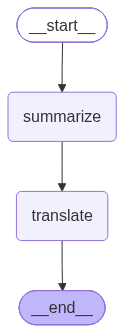

In [10]:
class AgentState(TypedDict):
    input_text: str
    summary: str
    translated_summary: str


def translate_step(state: AgentState) -> AgentState:
    """Translate text"""
    
    # Initialize the OpenAI model and define the prompt
    llm = ChatOpenAI(model = "gpt-4o-mini")
    prompt = f"Please translate from english to spanish: {state['summary']}"
    
    # Get the summary directly from the model
    result = llm.invoke([prompt])
    
    # Update the state with our summary
    return {
        "input_text": state["input_text"],  # Keep the original text
        "summary": state["summary"],  # Add the summary
        "translated_summary": result.content
    }


# Let's define a stategraph with the "AgentState" we defined earlier
workflow = StateGraph(AgentState)

# Let's add a node, which is the summarize function we defined before
workflow.add_node("summarize", summarize_step)

# Let's define Edges, which define how data flows between nodes
workflow.add_edge("summarize", "translate") 

workflow.add_node("translate", translate_step)

workflow.set_entry_point("summarize")
workflow.compile()

In [11]:
# Example text to summarize
sample_text = """
    Electric cars are awesome! I love them so much! They work by using electricity stored in a battery pack to power an electric motor, which drives the wheels. 
    Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVS) use electric motors that are more efficient and produce zero emissions during operation. 
    When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car. 
    The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. 
    Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
    """
    
# Let's compile the graph
graph = workflow.compile() 

# Set up the initial state with the input text
initial_state = {
        "input_text": sample_text,
        "summary": "",
        "translated_summary": ""}
    
# Run the graph
result = graph.invoke(initial_state)
    
# Get the summary from the result
summary = result["summary"]
translation = result["translated_summary"]

# Print the results with clear labels and spacing
print("=== Generated Summary ===")
print(summary)

print("\n=== Translated Summary ===")
print(translation)

=== Generated Summary ===
Electric cars are efficient and environmentally friendly vehicles that use electricity stored in a battery to power an electric motor, providing instantaneous torque and zero emissions, with the added benefit of regenerative braking to improve efficiency.

=== Translated Summary ===
Los coches eléctricos son vehículos eficientes y respetuosos con el medio ambiente que utilizan electricidad almacenada en una batería para alimentar un motor eléctrico, proporcionando par instantáneo y cero emisiones, con el beneficio adicional de la frenada regenerativa para mejorar la eficiencia.


**PRACTICE OPPORTUNITY:**
- **Define a new function called sentiment_step(state: AgentState) -> AgentState. This function uses language models to classify the translated text as either positive, negative, or neutral.**
- **Update the AgentState and Graph to include a new "analyze_sentiment" node.**

In [12]:
# Define the shared state structure
class AgentState(TypedDict):
    input_text: str
    summary: str
    translated_summary: str
    sentiment: str  # <- state key

# Summarize step
def summarize_step(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini")
    prompt = f"Summarize this text:\n\n{state['input_text']}"
    result = llm.invoke([prompt])
    return {
        **state, # The syntax **state in Python means you're unpacking a dictionary — spreading out its key-value pairs.
        # Take everything from state (like "input_text", "summary", etc.). Then overwrite the "sentiment" key with a new value
        "summary": result.content
    }

# Translate step
def translate_step(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini")
    prompt = f"Please translate from English to Spanish: {state['summary']}"
    result = llm.invoke([prompt])
    return {
        **state,
        "translated_summary": result.content
    }

# Sentiment step
def sentiment_step(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini")
    prompt = f"Classify the sentiment of the following text as positive, negative, or neutral:\n\n{state['input_text']}"
    result = llm.invoke([prompt])
    return {
        **state,
        "sentiment": result.content.strip()
    }

# Define the graph
workflow = StateGraph(AgentState)

# Add nodes (use unique names)
workflow.add_node("summarize", summarize_step)
workflow.add_node("translate", translate_step)
workflow.add_node("analyze_sentiment", sentiment_step)  # Renamed to avoid conflict

# Define edges
workflow.add_edge("summarize", "translate")
workflow.add_edge("translate", "analyze_sentiment")  # Use renamed node

# Set entry point
workflow.set_entry_point("summarize")

# Compile the graph
graph = workflow.compile()

# Sample input
sample_text = """
Electric cars work by using electricity stored in a battery pack to power an electric motor, which drives the wheels. 
Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVs) use electric motors that are more efficient and produce zero emissions during operation. 
When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car. 
The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. 
Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
"""

# Initial state
initial_state = {
    "input_text": sample_text,
    "summary": "",
    "translated_summary": "",
    "sentiment": ""
}

# Run the workflow
result = graph.invoke(initial_state)

# Display results
print("=== Generated Summary ===")
print(result["summary"])

print("\n=== Translated Summary ===")
print(result["translated_summary"])

print("\n=== Sentiment ===")
print(result["sentiment"])

=== Generated Summary ===
Electric cars use electricity from a battery pack to power an electric motor, driving the wheels without producing emissions, unlike gasoline-powered vehicles. When the accelerator is pressed, the battery supplies power to the motor, providing instant torque. The battery can be recharged via external power sources like home chargers or public stations. Additionally, many electric cars incorporate regenerative braking to recapture energy during braking, enhancing efficiency.

=== Translated Summary ===
Los coches eléctricos utilizan electricidad de un paquete de baterías para alimentar un motor eléctrico, moviendo las ruedas sin producir emisiones, a diferencia de los vehículos de gasolina. Cuando se presiona el acelerador, la batería suministra energía al motor, proporcionando par instantáneo. La batería se puede recargar a través de fuentes de energía externas, como cargadores domésticos o estaciones públicas. Además, muchos coches eléctricos incorporan freno

# TASK 5: LANGGRAPH WITH SINGLE TOOL (WEB SEARCH) USING TOOLNODE & CONDITIONAL EDGE

Now, let's give our agent its first superpower: the ability to search the web using the Tavily tool. We'll `ToolNode` for handling tool execution.

**Changes:**

1.  **Tool Definition:** Define the `tavily_search_tool`.
2.  **Nodes:**
    *   Define `call_model_with_tools` node that binds the tool(s) to the LLM.
    *   Instantiate `ToolNode`: Create an instance of `ToolNode` with our list of tools.
3.  **Conditional Edge:** Use the `should_continue` function (which checks the last message for tool calls) to direct the flow.
4.  **Graph Construction:**
    *   Add the `call_model_with_tools` node ("agent").
    *   Add the instantiated `ToolNode` as the "action" node.
    *   Set the entry point to "agent".
    *   Add the conditional edge from "agent" based on `should_continue` to either "action" or `END`.
    *   Add a direct edge from "action" back to "agent".

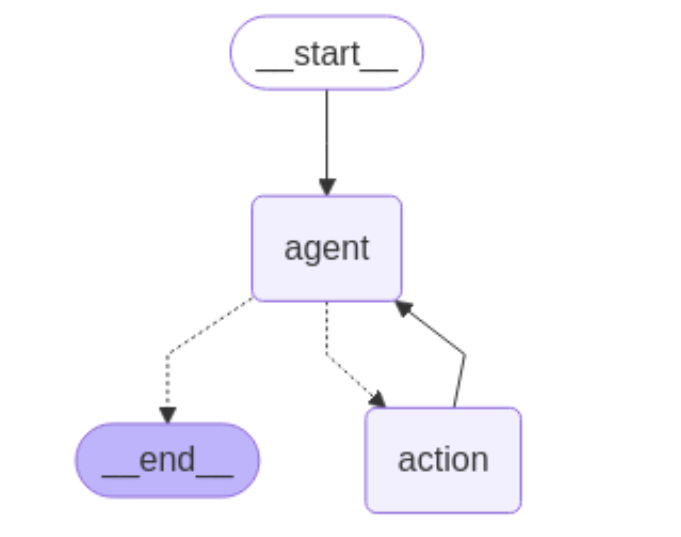

**Tavily AI:** For efficient web searches ([https://tavily.com/](https://tavily.com/)).

**Action:**

1.  Sign up for Tavily Self-Service API if you haven't already.
2.  Create a `.env` file in the same directory as this notebook (if you don't have one).
3.  Add your keys to the `.env` file like this:

```dotenv
OPENAI_API_KEY=sk-YourSecretOpenAIKey...
TAVILY_API_KEY=tvly-YourSecretTavilyKey...
```

Let's install the necessary libraries and load the keys.

In [20]:
tavily_api_key = os.environ["TAVILY_API_KEY"]
print(f"Tavily Key starts with: {tavily_api_key[:5]}...")

Tavily Key starts with: tvly-...


In [21]:
# Configure the OpenAI Client (using LangChain's wrapper)
# We use GPT-4o as it's generally better with tool calling
llm = ChatOpenAI(model = "gpt-4.1-mini", temperature = 0, streaming = True)
print("LangChain OpenAI Chat Model configured.")

LangChain OpenAI Chat Model configured.


In [22]:
# Define the Agent State
class AgentState(TypedDict):
    # AgentState is the name of the dictionary (used to represent the agent's state in the workflow).
    # It has one key: "messages", which holds a list of messages (e.g., from the user, model, or tools).
    # BaseMessage is the type used to represent each message in that list.
    # operator.add tells LangGraph to append new messages to the list during execution.
    messages: Annotated[Sequence[BaseMessage], operator.add]


In [23]:
# Let's set up our search tool that fetches results from Tavily (a search engine wrapper)
# Setting max_results to 3 limits the number of search results.

from langchain_community.tools.tavily_search import TavilySearchResults

tavily_search_tool = TavilySearchResults(max_results = 3)

# List of tools for this step
tools_list_single = [tavily_search_tool]

C:\Users\hp\AppData\Local\Temp\ipykernel_14088\641939954.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search_tool = TavilySearchResults(max_results = 3)


In [24]:
# Let's define call_model_with_tools node that binds the tool(s) to the LLM.
# This format is useful when you want to reuse the same model logic with different tools.
# You're building modular, reusable parts for your AI workflow (like LangGraph nodes).
# The Outer function (make_call_model_with_tools(tools)):
# It knows about the tools and returns a customized inner function.

# Inner function (call_model_with_tools(state)): This is the execution function. 
# It knows how to use the current state (conversation history) and actually runs the model with the tools that were set up by the outer function.

def make_call_model_with_tools(tools: list):
    def call_model_with_tools(state: AgentState):
        print("DEBUG: Entering call_model_with_tools node")
        messages = state["messages"]
        
        # Binds the tools to the language model 
        model_with_tools = llm.bind_tools(tools)

        # Feeds the conversation history (messages) into the model
        response = model_with_tools.invoke(messages)

        # Return the model response as a new message
        return {"messages": [response]}

    return call_model_with_tools


In [25]:
# Let's Define Conditional Edge Logic
# This function checks the most recent message in the state and decides whether to route to the 'action' node (ToolNode) or end.
# This function is used to control the flow of your agent, it's like a traffic signal deciding where to send the agent next.
# The function should_continue checks the last message in the agent's memory and decides:
# If the message includes a tool call, it routes to the next step (the action node, where the tool is actually used).
# If there's no tool call, it ends the conversation (__end__).


def should_continue(state: AgentState) -> Literal["action", "__end__"]:
    """Determines the next step: continue with tools or end."""
    print("DEBUG: Entering should_continue node")
    last_message = state["messages"][-1]
    
    # Check if the last message is an AIMessage with tool_calls
    if isinstance(last_message, AIMessage) and hasattr(last_message, "tool_calls") and last_message.tool_calls:
        print("DEBUG: Decision: continue (route to action)")
        return "action"  # Route to the node named "action"
    else:
        print("DEBUG: Decision: end (route to END)")
        return END  # Special value indicating the end of the graph

In [26]:
# ToolNode is a prebuilt ready-to-use node from LangGraph that is specifically designed to run external tools 
# like search, calculator, database query
from langgraph.prebuilt import ToolNode  

def build_graph_one_tool(tools_list):

    # Let's Instantiate ToolNode
    tool_node = ToolNode(tools_list)

    # Define the call_node_fn, which binds the tools to the LLM and calls OpenAI API
    call_node_fn = make_call_model_with_tools(tools_list)       

    # Build the Graph with One Tool using ToolNode
    graph_one_tool = StateGraph(AgentState)

    # Add nodes
    graph_one_tool.add_node("agent", call_node_fn)
    
    # Add the ToolNode instance directly, naming it "action"
    graph_one_tool.add_node("action", tool_node)

    # Set entry point
    graph_one_tool.set_entry_point("agent")

    # Add a conditional edge from the agent
    # The dictionary maps the return value of 'should_continue' ("action" or END)
    # to the name of the next node ("action" or the special END value).
    graph_one_tool.add_conditional_edges(
        "agent",  # Source node name
        should_continue,  # Function to decide the route
        {"action": "action", END: END},  # Mapping: {"decision": "destination_node_name"}
    )

    # Add edge from action (ToolNode) back to agent
    graph_one_tool.add_edge("action", "agent")

    # Compile the graph
    app = graph_one_tool.compile()

    # Visualize
    display(Image(app.get_graph().draw_mermaid_png()))

    return app

In [27]:
def app_call(app, messages):
    # Initialize the state with the provided messages
    initial_state = {"messages": [HumanMessage(content=messages)]}

    # Invoke the app with the initial state
    final_state = app.invoke(initial_state)

    # Iterate through the messages in the final state
    for i in final_state["messages"]:
        # Print the type of the message in markdown format
        print_markdown(i.type)
        # Print the content of the message in markdown format
        print_markdown(i.content)
        # Print any additional kwargs associated with the message
        if i.additional_kwargs != {}:
            print(i.additional_kwargs)

    # Return the content of the last message and the final state
    return final_state["messages"][-1].content, final_state

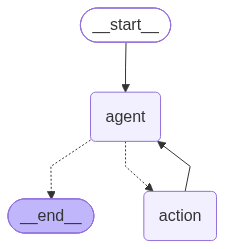

In [28]:
app = build_graph_one_tool(tools_list_single)

In [29]:
messages = "What's the latest news on France in May 2025? Is it a good time to visit?"
output, history = app_call(app, messages)

print("\n==================== OUTPUT ====================")
print(output)

print("\n==================== HISTORY ===================")
print(history)

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

What's the latest news on France in May 2025? Is it a good time to visit?

ai

tool

[{"title": "What's new for residents of France in May 2025", "url": "https://www.connexionfrance.com/news/whats-new-for-residents-of-france-in-may-2025/721952", "content": "Petrol and diesel prices remain above €2 per litre\n\n## Dover ferry services return to normal after anti-migration protest\n\nMasked demonstrators blocked access roads and briefly delayed sailings\n\n## Father creates pram friendly app for walks\n\nPramTrails offers parents in France pram-friendly walking routes, tailored to buggy models, terrain, gradients and nearby facilities\n\n## Choosing a vet in France: a British vet’s experience with pet care\n\nPeter Culpin explains how he chose a clinic for his ill cat, weighing online information, trust, kindness and clinical care\n\n## France looks to river barriers to cut plastic pollution\n\nToulouse project captures eight tonnes of plastic\n\n## Diesel prices rising: compare prices by retailer in France [...] ## End of free carte grise for electric vehicles\n\nFrom May 1, people buying electric and alternative-fuel vehicles will no longer benefit from a near-free carte grise registration document in France (outside of the Hauts-de-France region which has maintained an exemption to this fee).\n\nPreviously, those buying electric vehicles paid a fixed fee of €11 plus a €2.76 delivery charge.\n\nFrom May, standard rates of around €49 will apply, as for petrol or diesel vehicles.\n\n## 2025 energy aid voucher delayed to November\n\nThis year’s chèque énergie (energy vouchers) will not be sent until November 2025, the government has confirmed, in a change from the usual spring timetable.\n\nAmounts will range from €48 to €277, depending on income and household size. [...] Female workers asked to stay in backrooms and avoid coming into contact with group’s ‘spiritual leader’\n\n## First scallop shell road opens in Calvados\n\nCrushed scallop shells used to replace some cement, cutting carbon emissions from road construction\n\n ##### Lyon to include heat checks in home fitness tests\n ##### Britons jostle with Germans for Channel tourism\n ##### France's assisted dying law 'too restrictive', advocates say\n\n## France adopts new world map, moving on from Mercator\n\nUN backs drive to more accurately reflect the size of continents\n\nA view of an electric Fiat 500 being charged\n\n## Study suggests electric cars cost three times less to run than petrol cars in France\n\nPetrol and diesel prices remain above €2 per litre", "score": 0.8900749}, {"title": "Everything that changes in France in May 2025", "url": "https://www.thelocal.fr/20250422/everything-that-changes-in-france-in-may-2025", "content": "What changes in France Members only\n\n# Everything that changes in France in May 2025\n\nGenevieve Mansfield\n\nGenevieve Mansfield - genevieve.mansfield@thelocal.com \n\nPublished: 22 Apr, 2025 CET. Updated: Mon 28 Apr 2025 11:29 CET\n\n 1 comment\n\n Everything that changes in France in May 2025 \n\nProtesters hold a banner with the logos of the CGT, FSU and SUD trade unions and reading \"Mobilised for peace and social progress\" during a May Day (Labour Day) rally in 2024. (Photo by CHRISTOPHE SIMON / AFP)\n\n \n\nAdd The Local as a preferred source\n\nFrom three public holidays to possible rail strikes, plus tax deadlines, vehicle registration changes and the Cannes film festival, here's what is happening in France in May 2025.\n\nPublic holidays [...] Roland-Garros tennis tournament\n\nThe French Open begins on Sunday, May 25th and it will run until Sunday, June 8th. You can see the provisional schedule on the Roland-Garros website.\n\nImpending deadline for VAT rule changes\n\nFrance's 2025 budget, which passed in February, included a new VAT threshold for all businesses, which would force many self-employed people (micro entrepreneurs) into paying VAT for the first time.\n\n### Advertisement\n\nThis change has been controversial, and within hours of the budget being passed, it was announced the VAT reform would be paused until at least the end of May.\n\nREAD MORE: France’s micro-entrepreneurs in limbo over changes to VAT rules\n\nNew flights [...] Gas prices decrease\n\nThere is some good news for households who heat with gas. Starting on May 1st, the reference price per kilowatt-hour (kWh) will decrease by 6.4 percent, from €0.12412 to €0.1162.\n\nThis means that households who heat with gas would see an average saving of €90 a year, assuming they consume the standard amount (11,500kWh per year). In this case, their annual bill would drop from an average of €1,427 to €1,336.\n\nFor households who use gas solely for cooking or heating water, their reference price is also set to fall from €0.1530 to €0.1451 per kWh, representing a decrease of 5.12 percent.\n\nBenefits increased to reflect inflation", "score": 0.8815438}, {"title": "Key cultural dates for France in May 2025", "url": "https://www.connexionfrance.com/practical/key-cultural-dates-for-france-in-may-2025/719704", "content": "May 17: European Night of Museums. Hundreds of museums across the EU will open until the early hours of Sunday morning to welcome visitors, with many offering free entry.\n\n This includes the Musée des Arts et Métiers and Monnaie de Paris in the capital. Check official websites for museums close to you.\n\nMay 23: Fête des Voisins. Now in its 25th year, the event encourages neighbours to become better acquainted over an apéro or meal.\n\nMay 25: Fête des Mères. In France, Mother's Day is usually celebrated on the last Sunday of May, except when it is occupied by Pentecost, in which case it is postponed to the first Sunday of June.\n\n, the second of the four Grand Slam tennis events every year, begins in Paris. [...] May 13 to 24: The Cannes Film Festival (Festival de Cannes), one of the most prestigious events on the cinematic circuit, will this year be hosted by Laurent Lafitte.\n\nThe actor played French businessman and politician Bernard Tapie in the recent Netflix mini-series Class Act.\n\n## Key practical dates for France in May 2025\n\nMay 17: The final of the 2025 Eurovision Song Contest will be held in Basel, Switzerland. France is represented by Louane with the song Maman. \n\nThe singer/actress came to prominence on reaching the semi-final of The Voice in 2013 and is also known for her role in the 2014 film La Famille Bélier, for which she won a César. [...] May 25: The Monaco Grand Prix takes place over 78 laps of the 3.337km Circuit de Monaco in Monte Carlo\n\nThroughout May: David Hockney 25 is at Fondation Louis Vuitton, Paris, until August 31. The British artist’s biggest show to date comprises 400 works from 1955 to 2025.\n\npractical\n\n### More from The Connexion\n\n \n\n  #### Eiffel Tower reopens after strike over removal of female staff during Hindu visit\n\n  Female workers asked to stay in backrooms and avoid coming into contact with group’s ‘spiritual leader’\n \n\n  #### Britons in France dismayed after Ryanair cuts winter flights in south\n\n  ‘It is like running a bus service when you feel it might be profitable, but not taking into account the needs of the community it serves’", "score": 0.8795718}]

ai

The latest news and updates about France in May 2025 include:

- Petrol and diesel prices remain above €2 per litre.
- Dover ferry services have returned to normal after anti-migration protests.
- New pram-friendly walking app "PramTrails" launched for parents.
- France is working on river barriers to cut plastic pollution.
- The free carte grise registration for electric vehicles has ended, with standard rates now applying.
- The 2025 energy aid voucher distribution is delayed until November.
- The first scallop shell road opened in Calvados, reducing carbon emissions.
- Gas prices are decreasing by about 6.4%, offering some savings on heating bills.
- Several cultural events are happening, including the Cannes Film Festival (May 13-24), European Night of Museums (May 17), Fête des Voisins (May 23), Mother's Day (May 25), and the Monaco Grand Prix (May 25).
- The French Open tennis tournament starts on May 25 and runs until June 8.

Regarding whether it is a good time to visit, May is a lively month with many cultural events and festivals. However, fuel prices are high, and there may be some disruptions due to protests or strikes, though ferry services have normalized. The weather in May is generally pleasant for travel and sightseeing.

Overall, May 2025 can be a good time to visit France if you enjoy cultural events and mild spring weather, but be prepared for some potential travel inconveniences and higher fuel costs.


==================== OUTPUT ====================
The latest news and updates about France in May 2025 include:

- Petrol and diesel prices remain above €2 per litre.
- Dover ferry services have returned to normal after anti-migration protests.
- New pram-friendly walking app "PramTrails" launched for parents.
- France is working on river barriers to cut plastic pollution.
- The free carte grise registration for electric vehicles has ended, with standard rates now applying.
- The 2025 energy aid voucher distribution is delayed until November.
- The first scallop shell road opened in Calvados, reducing carbon emissions.
- Gas prices are decreasing by about 6.4%, offering some savings on heating bills.
- Several cultural events are happening, including the Cannes Film Festival (May 13-24), European Night of Museums (May 17), Fête des Voisins (May 23), Mother's Day (May 25), and the Monaco Grand Prix (May 25).
- The French Open tennis tournament starts on May 25 and runs until June 8.

Re

**PRACTICE OPPORTUNITY:**
- **Change the input message to something that shouldn't require web search (e.g., "What is 2 + 2?"**.
- **Rerun the test section of the code cell above.**
- **Observe the DEBUG logs and Streaming output:**
  - **Does the `agent` node still run?** 
  - **Does `call_model_with_tools` show any `LLM Tool Calls`?** 
  - **Does the `should_continue` node decide to `end`?** 
  - **Does the `action` node (ToolNode) run?**

In [30]:
messages = "What is 2 + 2?"
output, history = app_call(app, messages)

print("\n==================== OUTPUT ====================")
print(output)

print("\n==================== HISTORY ===================")
print(history)

# Expected Observation:
# 1. DEBUG logs for 'call_model_with_tools' should show the LLM response, but NO tool calls requested.
# 2. DEBUG logs for 'should_continue' should show "Decision: end".
# 3. The 'action' node (ToolNode) should NOT be executed.
# 4. The final response should be the direct answer from the LLM (e.g., "4" or the story).
# This confirms the agent correctly bypasses the tool when the query doesn't warrant its use based on description/context.

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

What is 2 + 2?

ai

2 + 2 equals 4.


==================== OUTPUT ====================
2 + 2 equals 4.

==================== HISTORY ===================
{'messages': [HumanMessage(content='What is 2 + 2?', additional_kwargs={}, response_metadata={}), AIMessage(content='2 + 2 equals 4.', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_ee38530f4a', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--01a0875b-7642-7e12-9a7a-10f44103c02a', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 87, 'output_tokens': 9, 'total_tokens': 96, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}


# TASK 6: CREATE AND ADD A CUSTOM NEW TOOL

**Goal:** Show how to wrap any Python function as a LangChain tool so it can be automatically discovered and invoked by your agent.

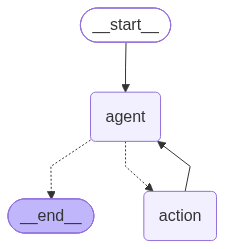

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

What is the current date?

ai

tool

2026-09-09

ai

The current date is September 9, 2026.

In [31]:
@tool
def get_current_date_tool():
    """Returns the current date in 'YYYY-MM-DD' format. Useful for finding flights/hotels relative to today."""
    return date.today().isoformat()


app_current_date = build_graph_one_tool([get_current_date_tool])

# Prepare your input

prompt = "What is the current date?"
output, history = app_call(app_current_date, prompt)

**PRACTICE OPPORTUNITY:** 
- **Come up with a new tool that the AI agent can use to do addition and subtraction.**
- **Add the tool to the list of tools and test the agent with the new tool.**

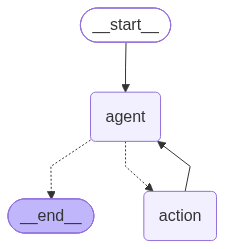


Graph built for Math Tool.

Testing Math Tool (Query: 'What is 123.5 + 456.7?')...
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Executing Math Tool: 123.5 add 456.7
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

What is 123.5 + 456.7?

ai

tool

The result of 123.5 + 456.7 is 580.2

ai

123.5 + 456.7 equals 580.2.


--- Final Output (Addition) ---


123.5 + 456.7 equals 580.2.

In [32]:
# 1. Define the Math Tool
@tool
def simple_math_tool(operand1: float, operand2: float, operation: Literal["add", "subtract"]):
    """
    Performs simple addition or subtraction on two numbers.
    Specify 'add' or 'subtract' for the operation.
    """
    print(f"DEBUG: Executing Math Tool: {operand1} {operation} {operand2}")
    if operation == "add":
        result = operand1 + operand2
        return f"The result of {operand1} + {operand2} is {result}"
    elif operation == "subtract":
        result = operand1 - operand2
        return f"The result of {operand1} - {operand2} is {result}"
    else:
        return "Invalid operation specified. Use 'add' or 'subtract'."


# 2. Build a graph specifically for this tool (or add it to another list)
tools_list_po = [simple_math_tool]
app_po = build_graph_one_tool(tools_list_po)
print("\nGraph built for Math Tool.")

# 3. Test with math queries
query_add = "What is 123.5 + 456.7?"
print(f"\nTesting Math Tool (Query: '{query_add}')...")
output_add, _ = app_call(app_po, query_add)
print("\n--- Final Output (Addition) ---")
print_markdown(output_add)


# TASK 7: LEVERAGE LANGGRAPH TO PERFORM FLIGHT SEARCH USING DUFFEL & `ToolNode`

Our Travel Agent needs access to several services:

*   **OpenAI:** For the core LLM reasoning.
*   **Duffel:** For flight and accommodation search. Duffel uses one access token for API authentication ([https://duffel.com/](https://duffel.com/)).

**Action:**

1. Sign up for Duffel if you have not already.
2. Create a `.env` file in the same directory as this notebook.
3. Add your keys like this:

```dotenv
DUFFEL_ACCESS_TOKEN=duffel_test_your_token_here
```

Duffel uses a single access token, not separate client ID and secret values.

In [33]:
# Load Duffel environment variables
from dotenv import load_dotenv
import os

load_dotenv(override=True)

duffel_access_token = os.environ["DUFFEL_ACCESS_TOKEN"]
print(f"Duffel Token starts with: {duffel_access_token[:5]}...")

Duffel Token starts with: duffe...


In [34]:
# Duffel REST client configuration
import requests

DUFFEL_API_BASE_URL = "https://api.duffel.com"
duffel_headers = {
    "Authorization": f"Bearer {duffel_access_token}",
    "Duffel-Version": "v2",
    "Content-Type": "application/json",
}

print("Duffel API client configured.")

Duffel API client configured.


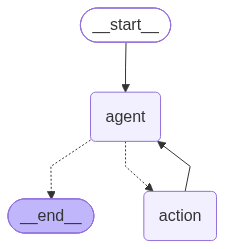

In [ ]:
@tool
def search_flights_tool(
    origin_code: str,
    destination_code: str,
    departure_date: str,
    return_date: str | None = None,
    adults: int = 1,
    travel_class: str = "economy",
    currency: str = "USD",
    max_offers: int = 5,
):
    """
    Searches flight offers through Duffel's Air Offer Requests API.
    Use IATA airport or city codes and future dates in YYYY-MM-DD format.
    travel_class must be economy, premium_economy, business, or first.
    """
    from datetime import date, datetime

    try:
        departure = datetime.strptime(departure_date, "%Y-%m-%d").date()
        return_trip = (
            datetime.strptime(return_date, "%Y-%m-%d").date()
            if return_date
            else None
        )
    except ValueError:
        return "Invalid date. Use YYYY-MM-DD, for example 2027-06-07."

    if departure < date.today():
        return f"Departure date {departure_date} is in the past. Please provide a future date."
    if return_trip and return_trip < departure:
        return "Return date must be on or after the departure date."

    print(
        f"DEBUG: Calling Duffel Flight Search - "
        f"{origin_code}->{destination_code}, Depart {departure_date}, "
        f"Return {return_date}, Adults {adults}, Class {travel_class}"
    )

    slices = [
        {
            "origin": origin_code.upper(),
            "destination": destination_code.upper(),
            "departure_date": departure_date,
        }
    ]
    if return_date:
        slices.append(
            {
                "origin": destination_code.upper(),
                "destination": origin_code.upper(),
                "departure_date": return_date,
            }
        )

    payload = {
        "data": {
            "slices": slices,
            "passengers": [{"type": "adult"} for _ in range(adults)],
            "cabin_class": travel_class.lower(),
        }
    }

    response = requests.post(
        f"{DUFFEL_API_BASE_URL}/air/offer_requests",
        headers=duffel_headers,
        json=payload,
        timeout=60,
    )
    if not response.ok:
        try:
            details = response.json().get("errors", response.text)
        except ValueError:
            details = response.text
        return f"Duffel flight search failed ({response.status_code}): {details}"

    offers = response.json().get("data", {}).get("offers", [])
    if not offers:
        return f"No Duffel flight offers found for {origin_code} to {destination_code}."

    results = []
    for offer in offers[:max_offers]:
        owner = offer.get("owner", {}).get("name", "Unknown airline")
        price = offer.get("total_amount", "N/A")
        offer_currency = offer.get("total_currency", currency)
        offer_slices = offer.get("slices", [])
        itinerary = offer_slices[0] if offer_slices else {}
        segments = itinerary.get("segments", [])
        if segments:
            departure_time = segments[0].get("departing_at", "N/A")[:16].replace("T", " ")
            arrival_time = segments[-1].get("arriving_at", "N/A")[:16].replace("T", " ")
        else:
            departure_time, arrival_time = "N/A", "N/A"
        results.append(
            f"{owner} | {departure_time} -> {arrival_time} | {price} {offer_currency} | "
            f"Offer ID: {offer.get('id', 'N/A')}"
        )

    return "Found Duffel flight offers:\n- " + "\n- ".join(results)


# Create the flight-search tool list and LangGraph app.
tools_list_full = [
    get_current_date_tool,
    search_flights_tool,
]
app_flight_search = build_graph_one_tool(tools_list_full)

In [37]:
# Prepare your input with an explicit future date.
prompt = "I want to go to Paris from Toronto during the first week of June 2027. Can you find flight options for 2 adults?"
output, history = app_call(app_flight_search, prompt)

print("\n==================== OUTPUT ====================")
print(output)

print("\n==================== HISTORY ===================")
print(history)

DEBUG: Entering call_model_with_tools node


DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Calling Duffel Flight Search - YYZ->CDG, Depart 2027-06-01, Return 2027-06-07, Adults 2, Class economy
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

I want to go to Paris from Toronto during the first week of June 2027. Can you find flight options for 2 adults?

ai

...

tool

Found Duffel flight offers:
- British Airways | 2027-06-01 00:00 -> 2027-06-01 14:36 | 867.22 AUD | Offer ID: off_0000BADywGDZb84tEB77Mg
- Iberia | 2027-06-01 00:00 -> 2027-06-01 14:36 | 898.42 AUD | Offer ID: off_0000BADywGEHYUe3GNRgT8
- Duffel Airways | 2027-06-01 00:00 -> 2027-06-01 14:36 | 922.42 AUD | Offer ID: off_0000BADywGDZb84tEB77MP
- American Airlines | 2027-06-01 00:00 -> 2027-06-01 14:36 | 944.84 AUD | Offer ID: off_0000BADywGEdXAvdHTby1b
- Aer Lingus | 2027-06-01 17:35 -> 2027-06-02 09:40 | 2285.42 AUD | Offer ID: off_0000BADywQwxhEKIVqQVUm

ai

I found several flight options for 2 adults from Toronto (YYZ) to Paris (CDG) during the first week of June 2027, departing on June 1st and returning on June 7th:

1. British Airways - 867.22 AUD
2. Iberia - 898.42 AUD
3. Duffel Airways - 922.42 AUD
4. American Airlines - 944.84 AUD
5. Aer Lingus - 2285.42 AUD

If you want more details or want to book any of these, please let me know!


==================== OUTPUT ====================
I found several flight options for 2 adults from Toronto (YYZ) to Paris (CDG) during the first week of June 2027, departing on June 1st and returning on June 7th:

1. British Airways - 867.22 AUD
2. Iberia - 898.42 AUD
3. Duffel Airways - 922.42 AUD
4. American Airlines - 944.84 AUD
5. Aer Lingus - 2285.42 AUD

If you want more details or want to book any of these, please let me know!

==================== HISTORY ===================
{'messages': [HumanMessage(content='I want to go to Paris from Toronto during the first week of June 2027. Can you find flight options for 2 adults?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_8b33040d7b', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--01a0877f-14d6-7061-8151-354f071891f7', tool_calls=[{'name': 'get_current_d

**PRACTICE OPPORTUNITY:** 
- **Similar to how we built the flight search tool, build a tool to search for hotels in NYC.**
- **Modify the tool list to achieve this and test the pipeline using the following check-in and check-out dates 2025-10-01 to 2025-10-03.**

In [44]:
@tool
def search_hotels_tool(city_name: str, check_in_date: str, check_out_date: str, adults: int = 1):
    """Searches accommodation options through Duffel Stays.
    Requires Duffel Stays access, a city name, and dates in YYYY-MM-DD format.
    """
    print(
        f"DEBUG: Calling Duffel Stays Search - City: {city_name}, "
        f"Check-in: {check_in_date}, Check-out: {check_out_date}, Adults: {adults}"
    )

    payload = {
        "data": {
            "location": {"geography": {"city_name": city_name}},
            "check_in_date": check_in_date,
            "check_out_date": check_out_date,
            "rooms": [{"adults": adults}],
        }
    }

    response = requests.post(
        f"{DUFFEL_API_BASE_URL}/stays/search",
        headers=duffel_headers,
        json=payload,
        timeout=60,
    )

    if response.status_code == 403:
        return (
            "Duffel Stays access is forbidden for this API token (HTTP 403). "
            "Enable Stays in the Duffel dashboard or use a token with Stays access."
        )

    if not response.ok:
        try:
            details = response.json().get("errors", response.text)
        except ValueError:
            details = response.text
        return f"Duffel hotel search failed (HTTP {response.status_code}): {details}"

    stays = response.json().get("data", {}).get("results", [])
    if not stays:
        return f"No Duffel stays found in {city_name} for the requested dates."

    results = []
    for stay in stays[:5]:
        accommodation = stay.get("accommodation", {})
        name = accommodation.get("name", "Unknown accommodation")
        room = stay.get("rooms", [{}])[0]
        price = room.get("total_amount", stay.get("total_amount", "N/A"))
        currency = room.get("total_currency", stay.get("total_currency", ""))
        results.append(f"{name} | {price} {currency}")

    return "Found Duffel stay options:\n- " + "\n- ".join(results)

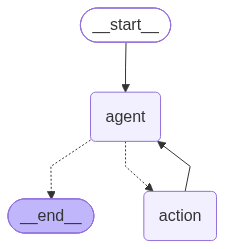

In [45]:
tools_list_full = [
    get_current_date_tool,
    search_flights_tool,
    search_hotels_tool
]

app_flight_search = build_graph_one_tool(tools_list_full)

In [46]:
# Prepare your input with future dates.
prompt = "I want to go to NYC. Find a hotel from 2027-10-01 to 2027-10-03."
output, history = app_call(app_flight_search, prompt)

print("\n==================== OUTPUT ====================")
print(output)

print("\n==================== HISTORY ===================")
print(history)

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Calling Duffel Stays Search - City: New York, Check-in: 2027-10-01, Check-out: 2027-10-03, Adults: 1
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

I want to go to NYC. Find a hotel from 2027-10-01 to 2027-10-03.

ai

tool

Duffel Stays access is forbidden for this API token (HTTP 403). Enable Stays in the Duffel dashboard or use a token with Stays access.

ai

I currently do not have access to search for hotels. However, I can help you find flights or provide other travel information if you want. Let me know how you'd like to proceed!


==================== OUTPUT ====================
I currently do not have access to search for hotels. However, I can help you find flights or provide other travel information if you want. Let me know how you'd like to proceed!

==================== HISTORY ===================
{'messages': [HumanMessage(content='I want to go to NYC. Find a hotel from 2027-10-01 to 2027-10-03.', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_8b33040d7b', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--01a08789-8151-75e1-a559-61e660dba79f', tool_calls=[{'name': 'search_hotels_tool', 'args': {'city_name': 'New York', 'check_in_date': '2027-10-01', 'check_out_date': '2027-10-03'}, 'id': 'call_LkY5YJQysUllsu3NiTgJhZlz', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 280, 'output_tokens': 40, 'total_to

# TASK 8: BRINGING IT ALL TOGETHER AND BUILD THE TRAVEL BOOKING AGENT

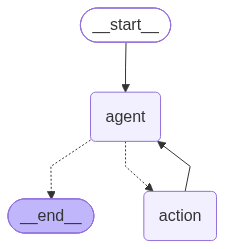

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Calling Duffel Flight Search - YYZ->JFK, Depart 2027-06-01, Return 2027-06-04, Adults 1, Class economy
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

I want the latest news about New York, I'm planning to visit from 2027-06-01 to 2027-06-04, leaving from Toronto. Please fetch security and travel advisories, find the cheapest flight for one adult. Finally, format the combined output.

ai

tool

...

[{"title": "New York Travelers Receive Urgent Worldwide Safety Warning", "url": "https://hudsonvalleypost.com/new-york-travelers-face-new-warning-from-u-s-officials", "content": "U.S. Navy, Getty Images\n\nU.S. Navy, Getty Images\n\nU.S. Navy, Getty Images\n\nThe Department of State advises Americans \"worldwide\" to exercise increased \"caution.\"\n\nTravelers are being advised to exercise increased caution, prepare for sudden flight cancellations or airspace closures, and closely monitor local news.\n\n\"We remind Americans of the continued need for caution and encourage them to monitor the news for breaking developments,\" the security alert adds. \"The Department of State advises Americans worldwide, and especially in the Middle East, to exercise increased caution. Americans abroad should follow the guidance in security alerts issued by the nearest U.S. embassy or consulate.\" [...] ### Federal Officials Issue Worldwide Travel Warning\n\nman standing inside airport looking at LED flight schedule bulletin board\n\nPhoto by Anete Lūsiņa on Unsplash\n\nman standing inside airport looking at LED flight schedule bulletin board\n\nFederal officials are warning of heightened tensions and a complex security environment that could spark unpredictable escalations.\n\nFor all the news that the Hudson Valley is sharing, make sure to follow Hudson Valley Post on Facebook, and download the Hudson Valley Post Mobile App\n\n\"Due to heightened tensions in the Middle East, the security environment remains complex with the potential for unforeseen escalation,\" U.S. officials stated in their security alert.\n\n### Security Alert: Worldwide Caution\n\nU.S. Navy, Getty Images\n\nU.S. Navy, Getty Images [...] Skip to site footer\n\n Trending:\n Sign up for HVP Newsletter\n Hudson Valley Traffic\n Weather\n Storm Center Reports, Closings & Delays\n 4th of July Fireworks\n\nHudson Valley Post\n\nNew York Travelers Receive Urgent Worldwide Safety Warning\n\nNew York Travelers Receive Urgent Worldwide Safety Warning\n\n# New York Travelers Receive Urgent Worldwide Safety Warning\n\nBobby Welber\n\nBobby Welber\n\nMajid Saeedi, Getty Images\n\n Share on Facebook\n Share on Twitter\n\nA new warning from federal officials impacts New Yorkers with upcoming trips. Here’s what you need to know.\n\nThe U.S. State Department is issuing an urgent worldwide safety alert for all American travelers, especially those in or heading to the Middle East.\n\n### Federal Officials Issue Worldwide Travel Warning", "score": 0.7361925}, {"title": "Hazardous travel advisory issued for NYC - NBC New York", "url": "https://www.nbcnewyork.com/video/local/hazardous-travel-advisory-issued-for-nyc/6448118", "content": "Hazardous travel advisory issued for NYC. Mayor Mamdani is encouraging New Yorkers to stay home this weekend and off the roads. Log in or create", "score": 0.72977066}, {"title": "Travel advisory issued in NYC: Things to know | PIX11", "url": "https://pix11.com/news/local-news/travel-advisory-issued-in-nyc-things-to-know", "content": "Please enter a search term.\n\n#### \n\n#### \n\n# Travel advisory issued in NYC: Things to know\n\nby: Ben Mitchell, Joe Punday, Video credit: Stacy-Ann Gooden\n\nPosted: Aug 27, 2026 / 07:34 AM EDT\n\nUpdated: Aug 27, 2026 / 07:34 AM EDT\n\nby: Ben Mitchell, Joe Punday, Video credit: Stacy-Ann Gooden\n\nPosted: Aug 27, 2026 / 07:34 AM EDT\n\nUpdated: Aug 27, 2026 / 07:34 AM EDT\n\nNEW YORK CITY (PIX11) — A travel advisory has been issued in New York City for parts of Thursday as a cold front moves into the region, bringing the potential for flash floods and severe thunderstorms.\n\nThe advisory will be in effect from 11 a.m. to 7 p.m., and a flood watch will take effect starting at noon. [...] Officials say there is a chance of localized heavy rain, which could flood streets, highways, and underpasses. Residents are advised to limit travel during severe weather and to never drive or walk through floodwaters.\n\nThe inclement weather should dissipate on Friday, as the cold front drifts offshore.\n\nTo get emergency updates, text NOTIFYNYC to 692-692.\n\nBen Mitchell is a digital content producer from Vermont who has covered both local and international news since 2021. He joined PIX11 in 2024. See more of his work here.\n\nCopyright 2026 Nexstar Media Inc. All rights reserved. This material may not be published, broadcast, rewritten, or redistributed.\n\n## Corduroy pants are trending for fall", "score": 0.7295395}]

tool

Found Duffel flight offers:
- Duffel Airways | 2027-06-01 00:00 -> 2027-06-01 01:22 | 71.85 AUD | Offer ID: off_0000BAE0ARXOPNFuLLi8TC

ai

Here is the combined information for your trip to New York from Toronto from 2027-06-01 to 2027-06-04:

Latest News about New York:
- There was a tragic accident on a recent Sunday resulting in five fatalities, with ongoing investigations.
- The Mayor is set to address the release of 9/11-related documents concerning air quality around the World Trade Center.
- There has been a rash of violence near the West Indian American Day Parade.
- Other news includes concerns about possible sewage discharge in a popular lake in Staten Island, the activation of Aaron Judge by the Yankees, and rising costs affecting Brooklyn Community Services' mobile shower bus.
- Weather forecasts indicate a warming trend with a slight chance of rain midweek.
(Source: CBS News New York, ABC7 Eyewitness News, NBC 4 New York)

Security and Travel Advisories for New York:
- The U.S. Department of State advises travelers to exercise increased caution due to a complex security environment and potential for sudden escalations.
- Travelers should prepare for possible flight cancellations or airspace closures and monitor local news closely.
- A hazardous travel advisory has been issued for parts of New York City due to a cold front bringing potential flash floods and severe thunderstorms. The advisory is in effect from 11 a.m. to 7 p.m. with a flood watch starting at noon. Residents are advised to limit travel during severe weather and avoid floodwaters.
(Source: Hudson Valley Post, NBC New York, PIX11)

Cheapest Flight Offer:
- Airline: Duffel Airways
- Departure: 2027-06-01 from Toronto (YYZ) to New York (JFK)
- Flight Time: 1 hour 22 minutes
- Price: 71.85 AUD
- Return: 2027-06-04 from New York (JFK) to Toronto (YYZ)

If you need assistance with booking or more details, please let me know!

In [48]:
tools = [
    tavily_search_tool,
    search_flights_tool,
    get_current_date_tool,
]

app_travel_agent = build_graph_one_tool(tools)

# Prepare your input with future dates.
prompt = "I want the latest news about New York, I'm planning to visit from 2027-06-01 to 2027-06-04, leaving from Toronto. Please fetch security and travel advisories, find the cheapest flight for one adult. Finally, format the combined output."
output, history = app_call(app_travel_agent, prompt)

In [49]:
print_markdown(output)

Here is the combined information for your trip to New York from Toronto from 2027-06-01 to 2027-06-04:

Latest News about New York:
- There was a tragic accident on a recent Sunday resulting in five fatalities, with ongoing investigations.
- The Mayor is set to address the release of 9/11-related documents concerning air quality around the World Trade Center.
- There has been a rash of violence near the West Indian American Day Parade.
- Other news includes concerns about possible sewage discharge in a popular lake in Staten Island, the activation of Aaron Judge by the Yankees, and rising costs affecting Brooklyn Community Services' mobile shower bus.
- Weather forecasts indicate a warming trend with a slight chance of rain midweek.
(Source: CBS News New York, ABC7 Eyewitness News, NBC 4 New York)

Security and Travel Advisories for New York:
- The U.S. Department of State advises travelers to exercise increased caution due to a complex security environment and potential for sudden escalations.
- Travelers should prepare for possible flight cancellations or airspace closures and monitor local news closely.
- A hazardous travel advisory has been issued for parts of New York City due to a cold front bringing potential flash floods and severe thunderstorms. The advisory is in effect from 11 a.m. to 7 p.m. with a flood watch starting at noon. Residents are advised to limit travel during severe weather and avoid floodwaters.
(Source: Hudson Valley Post, NBC New York, PIX11)

Cheapest Flight Offer:
- Airline: Duffel Airways
- Departure: 2027-06-01 from Toronto (YYZ) to New York (JFK)
- Flight Time: 1 hour 22 minutes
- Price: 71.85 AUD
- Return: 2027-06-04 from New York (JFK) to Toronto (YYZ)

If you need assistance with booking or more details, please let me know!

**PRACTICE OPPORTUNITY:** 
- **Assume that you plan to visit Paris in July. Test the tool to get obtain the latest news and find flights.**
- *Note that Amadeus free tool might have limited hotel search capability*

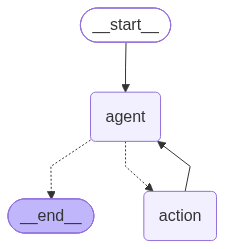

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Calling Duffel Flight Search - YYZ->CDG, Depart 2027-07-01, Return 2027-07-08, Adults 1, Class economy
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

I plan to visit Paris from 2027-07-01 to 2027-07-08. Find flights to Paris from Toronto and the best restaurants.

ai

tool

Found Duffel flight offers:
- Iberia | 2027-07-01 00:00 -> 2027-07-01 14:36 | 431.53 AUD | Offer ID: off_0000BAE0a0V2aCTg0KzjOi
- British Airways | 2027-07-01 00:00 -> 2027-07-01 14:36 | 444.46 AUD | Offer ID: off_0000BAE0a0VOYslG1RA0wq
- American Airlines | 2027-07-01 00:00 -> 2027-07-01 14:36 | 469.36 AUD | Offer ID: off_0000BAE0a0V2aCTg0KzjOr
- Duffel Airways | 2027-07-01 00:00 -> 2027-07-01 14:36 | 470.71 AUD | Offer ID: off_0000BAE0a0V2aCTg0KzjOf
- Air Transat | 2027-07-01 21:05 -> 2027-07-02 10:30 | 1279.80 AUD | Offer ID: off_0000BAE0aA8ik2Z7u0d2zg

tool

[{"title": "Where to Eat in Paris: Best Restaurants, Cafés, Food Experiences", "url": "https://maddysavenue.com/where-to-eat-in-paris", "content": "L’Assiette: This cozy restaurant in the 14th arrondissement serves up rustic country classics, like cassoulets, terrines, and wild game dishes. Come here for the famous cassoulet maison (a sumptuous stew of creamy beans, sausage, lamb, and pork) and a bottle of wine. Order the crème caramel for dessert. Perfection!\n Bistro Paul Bert: This classic, no-fuss French bistro in the 11th arrondissement features an extensive wine list to impress any sommelier and the most generous, delicious meat dishes. I’m still dreaming of the steak with spicy Sarawak pepper sauce and herby potatoes we had here. Bistro Paul Bert is among the best restaurants in Paris! [...] Without further ado, here are all the best places to eat in Paris!\n\nDelicious lunch and a glass of wine at a.lea in Paris, France\n\nSet lunch menu at a.lea\n\n Steak dish at Bistro Paul Bert\n\nSteak au poivre at Bistro Paul Bert\n\n \n\n### Best Traditional French Bistros in Paris\n\nReady to try perfect examples of classic French dishes, like steak frites and coq a vin? Foie gras, escargots, and terrine? Crème brûlée and chocolate mousse?\n\nHere are some of my favorite restaurants in Paris for classic French fare. Precisely none of them are on the typical tourist trail.\n\n Delicious lunch and a glass of wine at a.lea in Paris\n\nSet lunch menu at a.lea\n\n Cassoulet at L'Assiette in Paris\n\nCassoulet at L’Assiette [...] L’Etiquette on Île de la Cité\n Frenchie Bar à Vins in the 2nd arrondissement\n Stéréo in the 9th arrondissement\n Pétard, Giclette, Folderol, and Les Oillets in the 11th arrondissement\n Le Baron Rouge in the 12th arrondissement\n\nIf you love French wine, take it one step further with a Champagne day trip from Paris.\n\n## Paris Restaurant Map\n\nWant a handy Google Map pinned with all the can’t-miss cafés and best restaurants in Paris? All of my recommendations for where to eat in Paris are saved here!\n\n## Final Thoughts on Where to Eat in Paris\n\nAnd with that, you no longer have to wonder where to eat in Paris! From traditional French cuisine and cooking classes, to markets and picnic spots to the Seine River Dinner Cruise in Paris, you’re ready for the most delicious trip to Paris!", "score": 0.9039154}, {"title": "A Local Girl's Food Guide to Paris - Travelista", "url": "https://thetravelista.net/travel/food-guide-to-paris", "content": "## Best High End Restaurants in Paris\n\nIn a city as magnificent as Paris, it would be rude not to start at the ‘high end’. There are some timeless favourites included here, as well as some lesser-known spots.\n\n### Loulou Restaurant\n\nLoulou Restaurant is one of our top recommendations for the best places to eat in Paris thanks to its close proximity to the world-famous Louvre.\n\nAffording astonishing views of the iconic art gallery and museum from its stunning outdoor terrace, Loulou Restaurant cannot be missed on a local food tour of Paris!\n\nAddress: 107 Rue de Rivoli, 75001 Paris, France.\n\n### Hôtel Costes Restaurant\n\nSituated inside the 5-star Hôtel Costes, this restaurant is just a stone’s throw from the Louvre and boasts a charming bar and restaurant. [...] It’s been cited as “the world’s most famous bistro” by culinary connoisseurs and while many of the dishes on the menu come with a fairly hefty price tag, we think it’s worth it to dine at one of the best authentic French restaurants in Paris.\n\nAddress: 32 Rue du Vertbois, 75003 Paris, France.\n\n### La Poule au Pot\n\nLa Poule au Pot specialises in traditional French cuisines such as foie gras, French onion soup, beef and escargot.\n\nIt’s not one of the cheapest restaurants in Paris, but it is one of the best if you’re looking to indulge in quintessential Parisian dishes.\n\nAddress: 9 Rue Vauvilliers, 75001 Paris, France.\n\n### Le Relais de Venise [...] ### Le Relais de Venise\n\nDating all the way back to 1959 and situated just a 10-minute walk from the Arc de Triomphe, Le Relais de Venise is an unorthodox restaurant as it only offers one main dish; steak-frites.\n\nThey pride themselves on serving “one of the best steak-frites in town” and we can happily vouch for that claim because it’s one of our top recommendations in our food guide to Paris.\n\nAddress: 271 Bd Pereire, 75017 Paris, France.\n\n### Le Grand Colbert\n\nJust over the road from Jardin du Palais Royal, you’ll find an elegant brasserie menu consisting of dishes such as oysters, veal and Chateaubriand at Le Grand Colbert.\n\nAdorned with towering plants and elegant light fixtures, the romantic atmosphere at Le Grand Colbert is one of our favourites for date night in Paris.", "score": 0.8568246}, {"title": "10 Best Food Experiences in Paris", "url": "https://foodtravelist.com/10-best-food-experiences-in-paris", "content": "## 1. La Bourse et La Vie Bistro\n\nOne of our favorite foods to eat in Paris is steak frites and you can get this famous dish at almost any corner bistro. But if you’re looking for a superior, classic, and some of the best steak frites in Paris go to La Bourse et La Vie, the latest restaurant of Chef Daniel Rose. Everything about our meal was perfect. From the crispiest, tastiest frites to the huge yet airy cheese gougéres starter. You won’t want to eat it all for fear of ruining your dinner but will finish every bite. You must. It’s that good.\n\n## 2. Pierre Sang Bistro [...] ## 3. Le Monte Carlo Brasserie\n\nWhen we landed in Paris after a quick check-in at the sumptuous Hotel Napoleon we just had to have something to eat. A quick walk on the busy side streets and we found ourselves at Le Monte Carlo Brasserie. I love simple food to help recover from jet lag so the Poulet frites lunch special for me and the cassoulet of the day for Diana was just what the travel doctor ordered. Located a few blocks off the Champs Elysées this brasserie is a little gem.\n\nIf you get there at lunchtime you might have to wait a few minutes. The locals jammed this place during their work breaks for ample portions of homemade dishes and desserts. They’re open from 7 am to 10 pm. Sometimes the best food in Paris is simple and delicious. [...] Rungis Market produce\n\n## 8. La Grande Cascade\n\nDining at a Michelin-starred restaurant in Paris is always a treat and dining at the storied La Grand Cascade is just that. What’s truly unique about this restaurant is that it wasn’t always a restaurant. It was originally the lodge in Bois de Boulogne where Napoleon III would come to rest after hunting trips. The beautiful interior and exterior of the building have been maintained and are exquisite. I only wish we could have experienced the outdoor terrace, which looks like it would be a bit of an escape from the hustle and bustle on the busy streets of Paris. I can only imagine a gourmet meal here served to perfection on a glorious spring or summer day with a glass (or two) of champagne.", "score": 0.854509}]

ai

For your trip from Toronto to Paris from July 1, 2027, to July 8, 2027, here are some flight options:

1. Iberia, departing 2027-07-01, arriving 2027-07-01, price: 431.53 AUD
2. British Airways, departing 2027-07-01, arriving 2027-07-01, price: 444.46 AUD
3. American Airlines, departing 2027-07-01, arriving 2027-07-01, price: 469.36 AUD
4. Duffel Airways, departing 2027-07-01, arriving 2027-07-01, price: 470.71 AUD
5. Air Transat, departing 2027-07-01 21:05, arriving 2027-07-02 10:30, price: 1279.80 AUD

As for the best restaurants in Paris, here are some top recommendations:

- L’Assiette: Cozy restaurant in the 14th arrondissement known for rustic country classics like cassoulets and terrines.
- Bistro Paul Bert: Classic French bistro in the 11th arrondissement with generous meat dishes and an extensive wine list.
- Loulou Restaurant: Near the Louvre, offers stunning views and a great dining experience.
- Hôtel Costes Restaurant: Famous bistro with a charming bar, near the Louvre.
- La Poule au Pot: Specializes in traditional French cuisine like foie gras and escargot.
- Le Relais de Venise: Known for one main dish, steak-frites, near the Arc de Triomphe.
- Le Grand Colbert: Elegant brasserie with oysters, veal, and Chateaubriand, perfect for a romantic night.

Would you like more details on any of these flights or restaurants?

In [51]:
tools = [
    tavily_search_tool,
    search_flights_tool,
    get_current_date_tool,
    search_hotels_tool,
]

app_travel_agent = build_graph_one_tool(tools)

# Prepare your input with future dates.
prompt = "I plan to visit Paris from 2027-07-01 to 2027-07-08. Find flights to Paris from Toronto and the best restaurants."
output, history = app_call(app_travel_agent, prompt)

# TASK 9: INTEGRATING WITH GRADIO

Now we have our powerful, multi-tool LangGraph agent. Let's connect it to a Gradio `ChatInterface` for user interaction.

In [ ]:
def travel_agent_chat(user_input: str, history=None):
    tools_used = []
    stream = app_travel_agent.stream(
        {"messages": [HumanMessage(content=user_input)]},
        config={"recursion_limit": 15, "configurable": {"thread_id": str(uuid.uuid4())}},
    )

    # 1) Stream in tool calls and model tokens
    for chunk in stream:
        _, node = next(iter(chunk.items()))
        if isinstance(node, dict) and "messages" in node:
            for msg in node["messages"]:
                if isinstance(msg, ToolMessage):
                    if msg.name not in tools_used:
                        tools_used.append(msg.name)
                    yield f"\n\n **Tool:** {msg.name}\n{msg.content}\n\n—\n\n"
                elif isinstance(msg, AIMessage) and msg.content:
                    yield msg.content

    # 2) After streaming completes, yield a recap
    if tools_used:
        yield f"\n\n**Tools used this session:** {', '.join(tools_used)} \n\n — \n\n {msg.content}"



travel_chatbot_interface = gr.ChatInterface(
    fn = travel_agent_chat,
    chatbot = gr.Chatbot(
        height = 650,
        label = "AI Travel Agent",
        render_markdown = True,
    ),
    
    textbox = gr.Textbox(
        placeholder = "Plan your trip! Ask about attractions, flights, hotels...", container = False, scale = 7
    ),
    title = "✈️ LangGraph AI Travel Agent 🌍",
    description = "Your stateful travel assistant…",
    examples = [
        ["What are the top 3 tourist attractions in Tokyo (HND)?"],
        ["Find flights from London (LHR) to Paris (CDG) leaving next month for 4-day trip"],
        ["Book a hotel for 5 nights in NYC next month"],
    ],
    cache_examples = False,
)

travel_chatbot_interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7864
* Running on public URL: https://c47d171349821fd9e1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Calling Duffel Flight Search - LHR->CDG, Depart 2026-10-01, Return 2026-10-05, Adults 1, Class economy
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Calling Duffel Flight Search - CDG->LHR, Depart 2026-10-05, Return None, Adults 1, Class economy
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


# PRACTICE OPPORTUNITIES SOLUTIONS

**PRACTICE OPPORTUNITY SOLUTION:**
- **Change the input message to summarize a different text:**
"The internet is a global network that connects millions of computers and devices, allowing people to share information, communicate, and access services from anywhere in the world. It works by transmitting data through a complex system of servers, cables, and wireless signals. The internet has transformed how we live, work, and learn—making it easy to search for knowledge, shop online, stream videos, use social media, and stay in touch with others. It continues to evolve, shaping nearly every aspect of modern life."

- **Rerun the workflow and assess the output**

In [ ]:
sample_text = """The internet is a global network that connects millions of computers and devices, allowing people to share information, communicate, and access services from anywhere in the world. 
It works by transmitting data through a complex system of servers, cables, and wireless signals. 
The internet has transformed how we live, work, and learn—making it easy to search for knowledge, shop online, 
stream videos, use social media, and stay in touch with others. It continues to evolve, shaping nearly every aspect of modern life."""

# Let's compile the graph
graph = workflow.compile() 

# Set up the initial state with the input text
initial_state = {
        "input_text": sample_text,
        "summary": ""}
    
# Run the graph
result = graph.invoke(initial_state)
    
# Get the summary from the result
summary = result["summary"]
    
# Print the result
print(summary)


**PRACTICE OPPORTUNITY SOLUTION:**
- **Define a new function called sentiment_step(state: AgentState) -> AgentState. This function uses language models to classify the translated text as either positive, negative, or neutral.**
- **Update the AgentState and Graph to include a new "analyze_sentiment" node.**

In [ ]:
# Define the shared state structure
class AgentState(TypedDict):
    input_text: str
    summary: str
    translated_summary: str
    sentiment: str  # <- state key

# Summarize step
def summarize_step(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini")
    prompt = f"Summarize this text:\n\n{state['input_text']}"
    result = llm.invoke([prompt])
    return {
        **state, # The syntax **state in Python means you're unpacking a dictionary — spreading out its key-value pairs.
        # Take everything from state (like "input_text", "summary", etc.). Then overwrite the "sentiment" key with a new value
        "summary": result.content
    }

# Translate step
def translate_step(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini")
    prompt = f"Please translate from English to Spanish: {state['summary']}"
    result = llm.invoke([prompt])
    return {
        **state,
        "translated_summary": result.content
    }

# Sentiment step
def sentiment_step(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini")
    prompt = f"Classify the sentiment of the following text as positive, negative, or neutral:\n\n{state['input_text']}"
    result = llm.invoke([prompt])
    return {
        **state,
        "sentiment": result.content.strip()
    }

# Define the graph
workflow = StateGraph(AgentState)

# Add nodes (use unique names)
workflow.add_node("summarize", summarize_step)
workflow.add_node("translate", translate_step)
workflow.add_node("analyze_sentiment", sentiment_step)  # Renamed to avoid conflict

# Define edges
workflow.add_edge("summarize", "translate")
workflow.add_edge("translate", "analyze_sentiment")  # Use renamed node

# Set entry point
workflow.set_entry_point("summarize")

# Compile the graph
graph = workflow.compile()

# Sample input
sample_text = """
Electric cars work by using electricity stored in a battery pack to power an electric motor, which drives the wheels. 
Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVs) use electric motors that are more efficient and produce zero emissions during operation. 
When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car. 
The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. 
Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
"""

# Initial state
initial_state = {
    "input_text": sample_text,
    "summary": "",
    "translated_summary": "",
    "sentiment": ""
}

# Run the workflow
result = graph.invoke(initial_state)

# Display results
print("=== Generated Summary ===")
print(result["summary"])

print("\n=== Translated Summary ===")
print(result["translated_summary"])

print("\n=== Sentiment ===")
print(result["sentiment"])

**PRACTICE OPPORTUNITY SOLUTION:**
- **Change the input message to something that shouldn't require web search (e.g., "What is 2 + 2?"**.
- **Rerun the test section of the code cell above.**
- **Observe the DEBUG logs and Streaming output:**
  - **Does the `agent` node still run?** 
  - **Does `call_model_with_tools` show any `LLM Tool Calls`?** 
  - **Does the `should_continue` node decide to `end`?** 
  - **Does the `action` node (ToolNode) run?**

In [ ]:
messages = "What is 2 + 2?"
output, history = app_call(app, messages)

print("\n==================== OUTPUT ====================")
print(output)

print("\n==================== HISTORY ===================")
print(history)

# Expected Observation:
# 1. DEBUG logs for 'call_model_with_tools' should show the LLM response, but NO tool calls requested.
# 2. DEBUG logs for 'should_continue' should show "Decision: end".
# 3. The 'action' node (ToolNode) should NOT be executed.
# 4. The final response should be the direct answer from the LLM (e.g., "4" or the story).
# This confirms the agent correctly bypasses the tool when the query doesn't warrant its use based on description/context.

**PRACTICE OPPORTUNITY SOLUTION:**
- **Come up with a new tool that the agent can use to do addition and subtraction.**
- **Add the tool to the list of tools and test the agent with the new tool.**

In [ ]:
# 1. Define the Math Tool
@tool
def simple_math_tool(operand1: float, operand2: float, operation: Literal["add", "subtract"]):
    """
    Performs simple addition or subtraction on two numbers.
    Specify 'add' or 'subtract' for the operation.
    """
    print(f"DEBUG: Executing Math Tool: {operand1} {operation} {operand2}")
    if operation == "add":
        result = operand1 + operand2
        return f"The result of {operand1} + {operand2} is {result}"
    elif operation == "subtract":
        result = operand1 - operand2
        return f"The result of {operand1} - {operand2} is {result}"
    else:
        return "Invalid operation specified. Use 'add' or 'subtract'."


# 2. Build a graph specifically for this tool (or add it to another list)
tools_list_po = [simple_math_tool]
app_po = build_graph_one_tool(tools_list_po)
print("\nGraph built for Math Tool.")

# 3. Test with math queries
query_add = "What is 123.5 + 456.7?"
print(f"\nTesting Math Tool (Query: '{query_add}')...")
output_add, _ = app_call(app_po, query_add)
print("\n--- Final Output (Addition) ---")
print_markdown(output_add)


In [ ]:
query_subtract = "Calculate 100 minus 33.3"
print(f"\nTesting Math Tool (Query: '{query_subtract}')...")
output_subtract, _ = app_call(app_po, query_subtract)
print("\n--- Final Output (Subtraction) ---")
print_markdown(output_subtract)

# Expected Observation:
# - For both queries, the agent should identify the need for 'simple_math_tool'.
# - The DEBUG logs should show the correct operands and operation being passed.
# - The final output should contain the calculated result from the tool.

**PRACTICE OPPORTUNITY SOLUTION:**
- **Similar to the flight-search tool, build a tool to search for stays in NYC using Duffel.**
- **Modify the tool list and test the pipeline using check-in and check-out dates 2025-10-01 to 2025-10-03.**

In [ ]:
@tool
def search_hotels_tool(city_name: str, check_in_date: str, check_out_date: str, adults: int = 1):
    """Searches accommodation options through Duffel Stays.
    Requires a city name and dates in YYYY-MM-DD format.
    """
    print(
        f"DEBUG: Calling Duffel Stays Search - City: {city_name}, "
        f"Check-in: {check_in_date}, Check-out: {check_out_date}, Adults: {adults}"
    )

    payload = {
        "data": {
            "location": {"geography": {"city_name": city_name}},
            "check_in_date": check_in_date,
            "check_out_date": check_out_date,
            "rooms": [{"adults": adults}],
        }
    }

    response = requests.post(
        f"{DUFFEL_API_BASE_URL}/stays/search",
        headers=duffel_headers,
        json=payload,
        timeout=60,
    )
    response.raise_for_status()
    stays = response.json().get("data", {}).get("results", [])

    if not stays:
        return f"No Duffel stays found in {city_name} for the requested dates."

    results = []
    for stay in stays[:5]:
        accommodation = stay.get("accommodation", {})
        name = accommodation.get("name", "Unknown accommodation")
        room = stay.get("rooms", [{}])[0]
        price = room.get("total_amount", stay.get("total_amount", "N/A"))
        currency = room.get("total_currency", stay.get("total_currency", ""))
        results.append(f"{name} | {price} {currency}")

    return "Found Duffel stay options:\n- " + "\n- ".join(results)


In [ ]:
tools_list_full = [
    get_current_date_tool,
    search_flights_tool,
    search_hotels_tool
]

app_flight_search = build_graph_one_tool(tools_list_full)

In [ ]:
# Prepare your input with future dates.
prompt = "I want to go to NYC. Find a hotel from 2027-10-01 to 2027-10-03."
output, history = app_call(app_flight_search, prompt)

print("\n==================== OUTPUT ====================")
print(output)

print("\n==================== HISTORY ===================")
print(history)

**PRACTICE OPPORTUNITY SOLUTION:**
- **Assume that you plan to visit Paris in July. Test the tool to obtain the latest news and find flights.**
- *Duffel test access and available inventory may limit the returned flight or stay offers.*

In [ ]:
tools = [
    tavily_search_tool,
    search_flights_tool,
    get_current_date_tool,
    search_hotels_tool,
]

app_travel_agent = build_graph_one_tool(tools)

# Prepare your input
prompt = "I plan to visit Paris in July 2025, find flights to Paris from Toronto. Find best restaurants."
output, history = app_call(app_travel_agent, prompt)

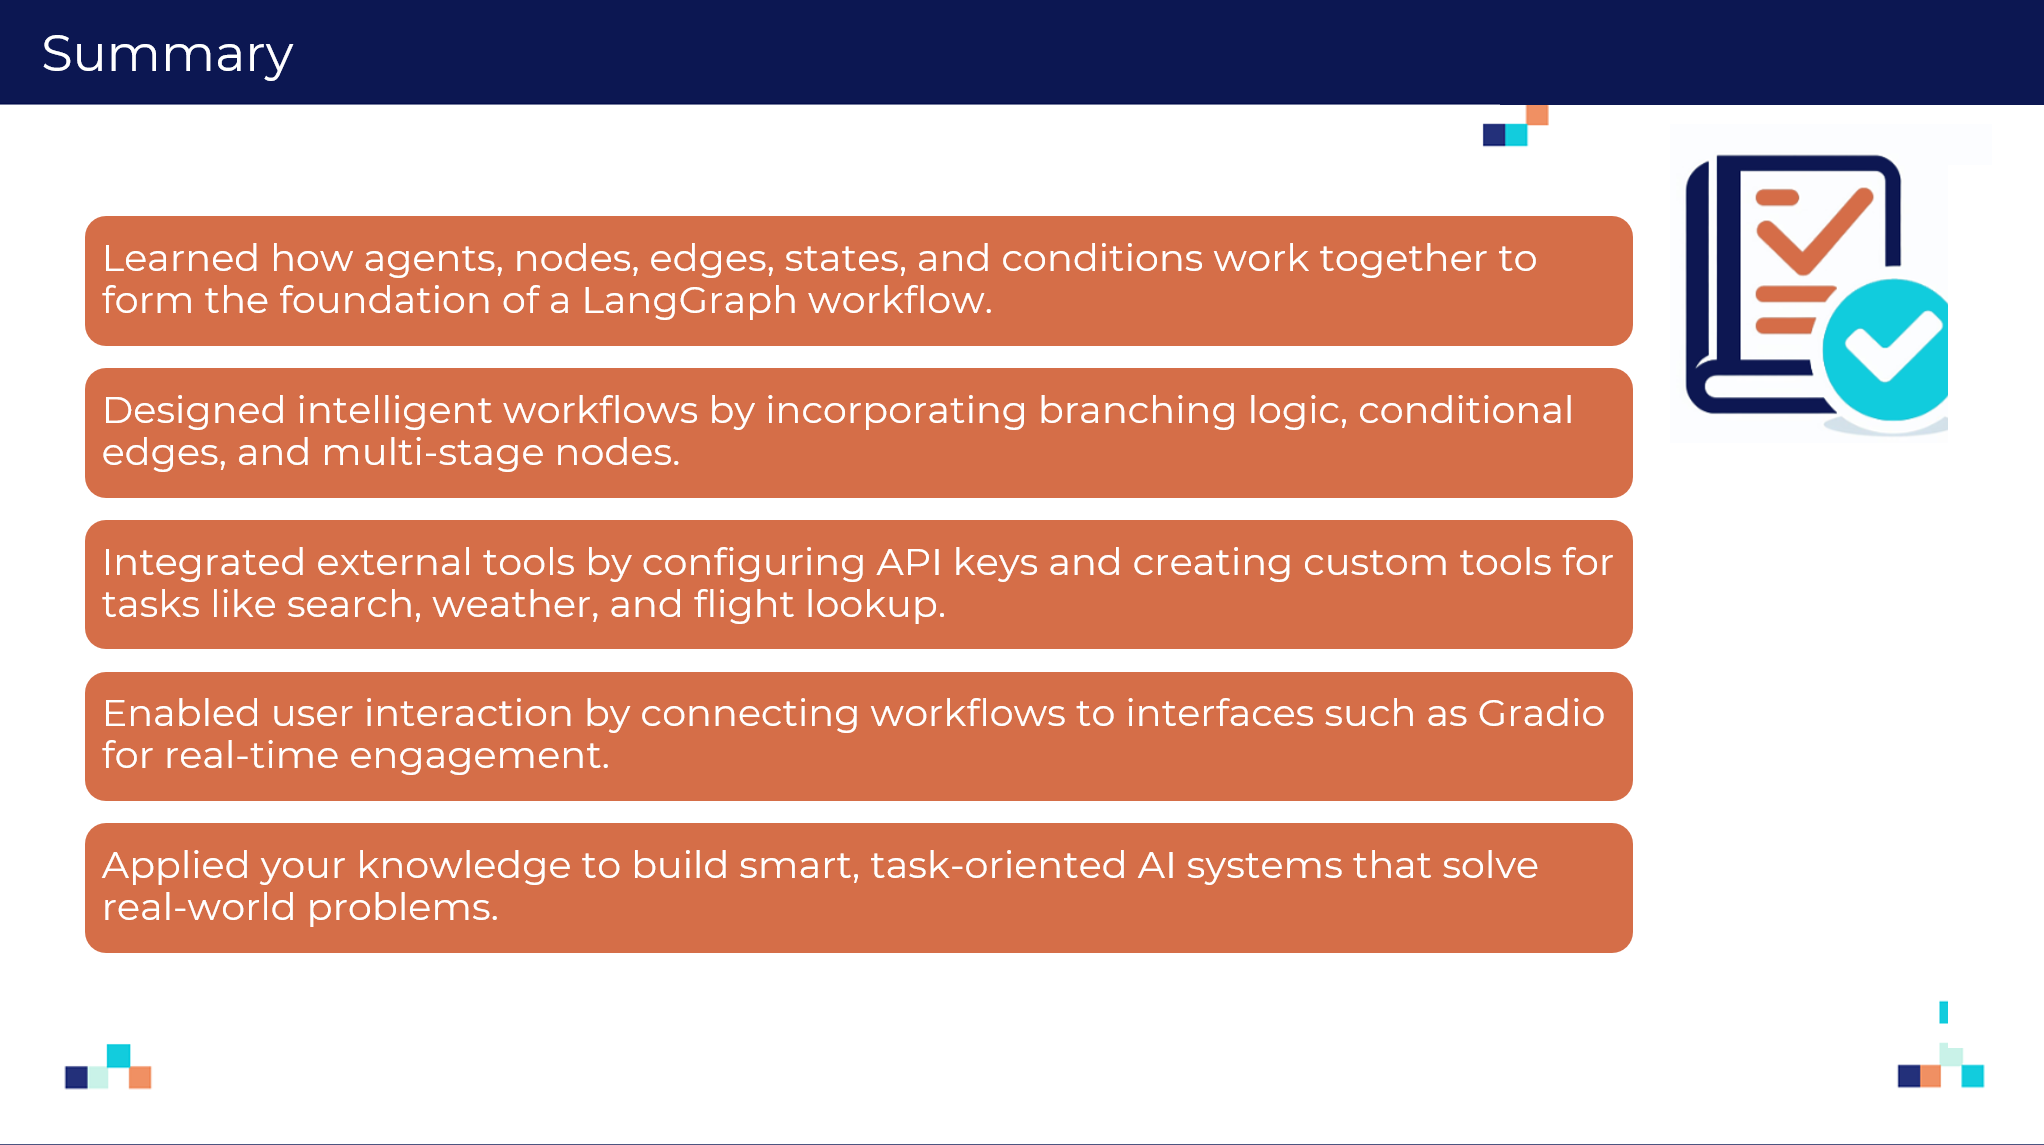

Would love to connect with you on LinkedIn: https://www.linkedin.com/in/dr-ryan-ahmed/

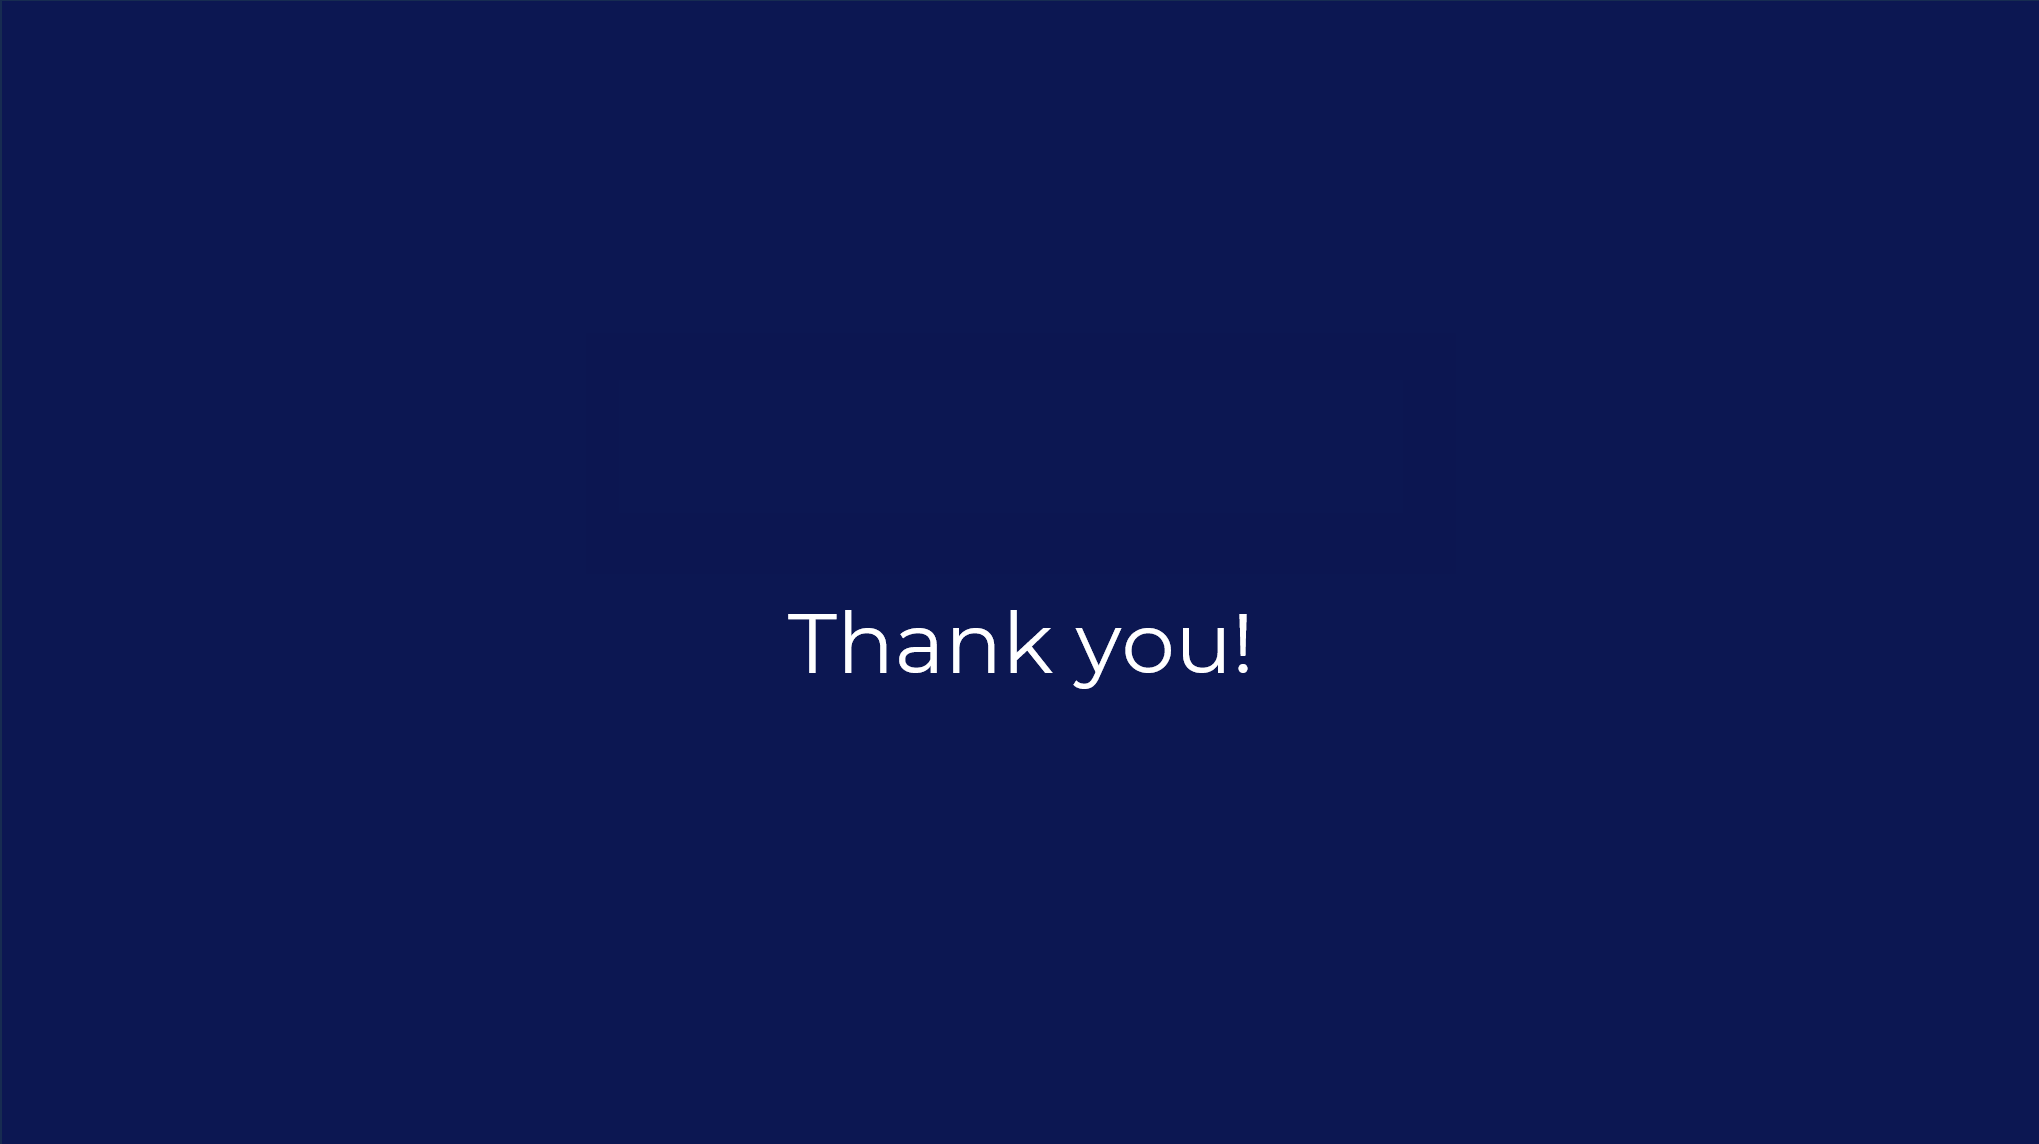